# Testing Feature engineering second try
Ram on - Paul McCartney

## 1. Defining the baseline for the classification system


- SOP and SPH defining criteria: 
- Notch filtering: 
- Window size options: 
- Preictal size for labeling:
- 


SOP and SPH:
* **SOP (Seizure Occurrence Period):** time window after the prediction horizon during which a seizure is expected to occur

* **SPH (Seizure Prediction Horizon):** minimum time between an alarm and seizure onset, ensuring a clinically useful warning period where no seizure should occur

* These parameters are **not derived from EEG data**, but are **predefined experimental design choices**

* Together, they define the **preictal period**:

  * from *(onset − (SPH + SOP))* to *(onset − SPH)*

* Typical values in the literature:

  * SOP ≈ 30 minutes
  * SPH ≈ 5–10 minutes

* They are usually chosen based on:

  * prior studies
  * clinical intuition
  * empirical tuning

* There is **no true physiological ground truth** for when the preictal state begins

* Therefore, preictal labeling is **an operational approximation**, which introduces **label uncertainty**

* This choice can significantly affect:

  * model performance
  * sensitivity vs false alarm trade-off

* Careful selection and justification of SOP/SPH is **critical in seizure prediction pipelines**



* **Example (typical setup):**

  * Seizure onset = **14:00**
  * **SPH = 5 min**
  * **SOP = 30 min**

* **Preictal period:**

  * from **13:25 to 13:55**
  * (i.e., onset − (SPH + SOP) → onset − SPH)

* **SPH (no-seizure buffer):**

  * from **13:55 to 14:00**
  * seizure should *not* occur here

* **Interpretation:**

  * If the model raises an alarm at **13:25**,
    the seizure is expected to happen between **13:55 and 14:25**

* **In window labeling (10 s windows):**

  * windows between **13:25–13:55 → preictal (label = 1)**
  * windows far from seizure → interictal (label = 0)**


## 2. Importing and sorting input data


### 2.1 Scan folder

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from pathlib import Path
from typing import Optional


def scan_npz_files(folder: str | Path) -> list[Path]:
    """Return a sorted list of .npz file paths found in *folder*."""
    folder = Path(folder)
    if not folder.is_dir():
        raise NotADirectoryError(f"Folder not found: {folder}")
    files = sorted(folder.glob("*.npz"))
    if not files:
        print(f"[WARNING] No .npz files found in: {folder}")
    return files


In [2]:
# Also accepts a Path object
files = scan_npz_files(Path("/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/results/XB47Y_28032026Normalized/"))

# Result: list of Path objects
#print(files)
Counter = 0
for path in files:
    Counter += 1
    #print(path.name)   # filename only:  'pat01.npz'
    #print(str(path))# full path:      'eeg_data/pat01.npz'
#print(Counter)
print(len(files)) #183 npz +  1 normalization global stats= 184

184


We need to take out the summary file from the rest. Simple: only the one that end with the suffix pre-proc

In [3]:
files = Path("/home/tperezsanchez/FoundationModel_EEG_Dissertation/EEG_data_vis/results/XB47Y_28032026Normalized/")
base_files = sorted(files.glob("*full.npz"))

print(f"Found {len(base_files)} .npz files")
#for f in base_files:
    #print(f"  {f.name}") 
    # print all the files names

Found 183 .npz files


### 2.2 load metadata
Created a function to correctly process the datetime data. Also there was a problem with T0/TF in files that contained seizures. Repetead values that were generated when each onset was stored in key. Repetead TO/TF per seizure event. 
So in order to solve this a "unique" selection mechanism was applied. 

In [4]:
rows = []
from datetime import datetime, timezone
import numpy as np


def parse_timestamp(val):
    """Accept Unix float, datetime string, or repeated timestamp arrays."""

    if isinstance(val, np.ndarray):
        flat = val.ravel()
        cleaned = [str(x).strip() for x in flat if str(x).strip() != ""]

        if len(cleaned) == 0:
            return None

        unique_vals = list(dict.fromkeys(cleaned))

        if len(unique_vals) == 1:
            val = unique_vals[0]
        else:
            raise ValueError(f"Timestamp array has multiple different values: {unique_vals}")

    try:
        return float(val)
    except (ValueError, TypeError):
        pass

    val = str(val).strip()
    dt = datetime.strptime(val, "%Y-%m-%d %H:%M:%S.%f")
    return dt.replace(tzinfo=timezone.utc).timestamp()
    
for base_NPZ_path in base_files:
    meta = {"file_name": base_NPZ_path.name, "file_path": str(base_NPZ_path.resolve()), "load_error": None}

    try:
        with np.load(base_NPZ_path, allow_pickle=True) as data:
            keys = set(data.files)
            # store data from key into meta df, convert them into float or str first
            
            meta["fs"]         = float(data["fs"]) if "fs" in keys else None
            meta["source_file"]= str(data["source_file"]) if "source_file" in keys else None
            meta["T0"] = parse_timestamp(data["T0"]) if "T0" in keys else None
            meta["TF"] = parse_timestamp(data["TF"]) if "TF" in keys else None
            meta["is_normalized"] = "mu" in keys and "sigma" in keys

            meta["channel_names"]  = list(data["channel_names"]) if "channel_names" in keys else []
            meta["seizure_onsets"] = list(data["seizure_onsets"]) if "seizure_onsets" in keys else []

            # Read X shape only — avoids loading the full array into memory
            if "X" in keys:
                shape = data["X"].shape
                meta["n_channels"] = int(shape[0]) if len(shape) == 2 else None
                meta["n_samples"]  = int(shape[1]) if len(shape) == 2 else None
            else:
                meta["n_channels"] = None
                meta["n_samples"]  = None

    except Exception as e:
        meta["load_error"] = str(e)
        print(f"❌ Failed to load {base_NPZ_path.name}: {e}")

    rows.append(meta)

print(f"\nLoaded metadata from {len(rows)} file(s)")


Loaded metadata from 183 file(s)


### 2.3 Temporal Sanity check

In [5]:
from datetime import datetime

for meta in rows:
    T0 = meta.get("T0")
    TF = meta.get("TF") 

    meta["start_time"] = datetime.fromtimestamp(T0) if T0 is not None else None
    meta["end_time"]   = datetime.fromtimestamp(TF) if TF is not None else None
    meta["duration_s"] = round(TF - T0, 3) if (T0 is not None and TF is not None) else None

    # Cross-check: does n_samples / fs match TF - T0?
    fs, n = meta.get("fs"), meta.get("n_samples")
    if fs and n and meta["duration_s"] is not None:
        expected = round(n / fs, 3)
        meta["duration_check_ok"] = abs(expected - meta["duration_s"]) < 1.0
    else:
        meta["duration_check_ok"] = None

bad = [m for m in rows if m["duration_check_ok"] is False]
print(len(bad), "files with duration mismatch")

0 files with duration mismatch


### 2.4 Dataframe construction

In [6]:
COLUMNS = [
    "file_name", "file_path",
    "start_time", "end_time", "duration_s",
    "fs", "n_channels", "n_samples",
    "channel_names", "seizure_onsets",
    "is_normalized", "source_file",
    "duration_check_ok", "load_error",
]

df = pd.DataFrame(rows, columns=COLUMNS)
df = df.sort_values("start_time", na_position="last").reset_index(drop=True)

print(df.shape)
df.head()

(183, 14)


,file_name,file_path,start_time,end_time,duration_s,fs,n_channels,n_samples,channel_names,seizure_onsets,is_normalized,source_file,duration_check_ok,load_error
0,XB47Y_35_preproc_full.npz,/home/tperezsanchez/FoundationModel_EEG_Disser...,2019-10-29 09:31:04,2019-10-29 10:01:00.730450,1796.730,207.031055,2,371979,"[EEG SQ_D-SQ_C, EEG SQ_P-SQ_C]",[nan],True,['XB47Y_35.mat'],True,None
1,XB47Y_37_preproc_full.npz,/home/tperezsanchez/FoundationModel_EEG_Disser...,2019-10-29 19:54:13,2019-10-30 01:54:12.759550,21599.760,207.031055,2,4471821,"[EEG SQ_D-SQ_C, EEG SQ_P-SQ_C]",[nan],True,['XB47Y_37.mat'],True,None
2,XB47Y_38_preproc_full.npz,/home/tperezsanchez/FoundationModel_EEG_Disser...,2019-10-30 01:54:13,2019-10-30 04:58:50.338150,11077.338,207.031055,2,2293353,"[EEG SQ_D-SQ_C, EEG SQ_P-SQ_C]",[nan],True,['XB47Y_38.mat'],True,None
3,XB47Y_98_preproc_full.npz,/home/tperezsanchez/FoundationModel_EEG_Disser...,2019-10-30 07:47:44,2019-10-30 13:47:44.759400,21600.759,207.031055,2,4472028,"[EEG SQ_D-SQ_C, EEG SQ_P-SQ_C]",[nan],True,['XB47Y_98.mat'],True,None
4,XB47Y_99_preproc_full.npz,/home/tperezsanchez/FoundationModel_EEG_Disser...,2019-10-30 13:47:44,2019-10-30 19:47:44.759400,21600.759,207.031055,2,4472028,"[EEG SQ_D-SQ_C, EEG SQ_P-SQ_C]",[nan],True,['XB47Y_99.mat'],True,None


### 2.5 Sanity report

In [7]:
print("── Sanity Report ──────────────────────────────────────")
print(f"  Total recordings   : {len(df)}")
print(f"  Load errors        : {df['load_error'].notna().sum()}")
print(f"  Missing T0/TF      : {df['start_time'].isna().sum()}")
print(f"  Duration check ✗   : {(df['duration_check_ok'] == False).sum()}")
print(f"  Missing fs         : {df['fs'].isna().sum()}")
print(f"  Normalized files   : {df['is_normalized'].sum()}")

# Check for overlapping recordings
valid = df.dropna(subset=["start_time", "end_time"]).sort_values("start_time")
overlaps = 0
for i in range(len(valid) - 1):
    if valid.iloc[i]["end_time"] > valid.iloc[i + 1]["start_time"]:
        overlaps += 1
print(f"  Overlapping pairs  : {overlaps}")
print("───────────────────────────────────────────────────────")

── Sanity Report ──────────────────────────────────────
  Total recordings   : 183
  Load errors        : 0
  Missing T0/TF      : 0
  Duration check ✗   : 0
  Missing fs         : 0
  Normalized files   : 183
  Overlapping pairs  : 75
───────────────────────────────────────────────────────


### 2.6 Clean onsets: solution to problems with "nan"

In [8]:
def clean_onsets(x):
    if isinstance(x, (list, np.ndarray)):
        return [i for i in x if not pd.isna(i)]
    elif pd.isna(x):
        return []
    else:
        return [x]

df["seizure_onsets_clean"] = df["seizure_onsets"].apply(clean_onsets)
#df[["seizure_onsets", "seizure_onsets_clean"]].head(20)

NOTE: it doesn't matter that they overlap, it is considered in the measurment.



## 3 Windowing 
Goal: create a df in which each row is a single window from a file

### 3.1 Check window size

In [9]:
window_sec = 10


fs = df.iloc[0]["fs"]

window_size = int(window_sec * fs)
# result should be 2070, because the fs is 207hz
print(window_size)

2070


### 3.2 Loop through every file, manual inspection

In [10]:

for idx, row in df.iterrows():
    
    file_path = row["file_path"]
    
    data = np.load(file_path, allow_pickle=True)
    
    X = data["X"]   # shape: (C, N)
    
    print(row["file_name"], X.shape)

XB47Y_35_preproc_full.npz (2, 371979)
XB47Y_37_preproc_full.npz (2, 4471821)
XB47Y_38_preproc_full.npz (2, 2293353)
XB47Y_98_preproc_full.npz (2, 4472028)
XB47Y_99_preproc_full.npz (2, 4472028)
XB47Y_100_preproc_full.npz (2, 4472028)
XB47Y_101_preproc_full.npz (2, 2408445)
XB47Y_39_preproc_full.npz (2, 4471821)
XB47Y_40_preproc_full.npz (2, 4472028)
XB47Y_41_preproc_full.npz (2, 4472028)
XB47Y_42_preproc_full.npz (2, 3530178)
XB47Y_102_preproc_full.npz (2, 4472028)
XB47Y_103_preproc_full.npz (2, 4472028)
XB47Y_104_preproc_full.npz (2, 4472028)
XB47Y_105_preproc_full.npz (2, 2872332)
XB47Y_43_preproc_full.npz (2, 4471821)
XB47Y_44_preproc_full.npz (2, 2082627)
XB47Y_45_preproc_full.npz (2, 59823)
XB47Y_46_preproc_full.npz (2, 4472028)
XB47Y_47_preproc_full.npz (2, 4472028)
XB47Y_48_preproc_full.npz (2, 1070604)
XB47Y_106_preproc_full.npz (2, 4472028)
XB47Y_107_preproc_full.npz (2, 3867588)
XB47Y_108_preproc_full.npz (2, 4471821)
XB47Y_109_preproc_full.npz (2, 2600955)
XB47Y_49_preproc_f

### 3.3 Calculate number of windows per file

In [11]:
for idx, row in df.iterrows():
    
    file_path = row["file_path"]
    data = np.load(file_path, allow_pickle=True)
    
    X = data["X"]   # (C, N)
    
    N = X.shape[1]
    
    n_windows = N // window_size
    
    print(row["file_name"], "->", n_windows)

XB47Y_35_preproc_full.npz -> 179
XB47Y_37_preproc_full.npz -> 2160
XB47Y_38_preproc_full.npz -> 1107
XB47Y_98_preproc_full.npz -> 2160
XB47Y_99_preproc_full.npz -> 2160
XB47Y_100_preproc_full.npz -> 2160
XB47Y_101_preproc_full.npz -> 1163
XB47Y_39_preproc_full.npz -> 2160
XB47Y_40_preproc_full.npz -> 2160
XB47Y_41_preproc_full.npz -> 2160
XB47Y_42_preproc_full.npz -> 1705
XB47Y_102_preproc_full.npz -> 2160
XB47Y_103_preproc_full.npz -> 2160
XB47Y_104_preproc_full.npz -> 2160
XB47Y_105_preproc_full.npz -> 1387
XB47Y_43_preproc_full.npz -> 2160
XB47Y_44_preproc_full.npz -> 1006
XB47Y_45_preproc_full.npz -> 28
XB47Y_46_preproc_full.npz -> 2160
XB47Y_47_preproc_full.npz -> 2160
XB47Y_48_preproc_full.npz -> 517
XB47Y_106_preproc_full.npz -> 2160
XB47Y_107_preproc_full.npz -> 1868
XB47Y_108_preproc_full.npz -> 2160
XB47Y_109_preproc_full.npz -> 1256
XB47Y_49_preproc_full.npz -> 2160
XB47Y_50_preproc_full.npz -> 2160
XB47Y_51_preproc_full.npz -> 2160
XB47Y_52_preproc_full.npz -> 1510
XB47Y_11

### 3.4 Iterate per window, NONE is saved

In [12]:
for idx, row in df.iterrows():
    
    file_path = row["file_path"]
    data = np.load(file_path, allow_pickle=True)
    
    X = data["X"]
    fs = row["fs"]
    
    window_size = int(10 * fs)
    N = X.shape[1]
    n_windows = N // window_size
    
    for w in range(n_windows):
        
        start = w * window_size
        end = start + window_size
        
        window = X[:, start:end]
        
        print(window.shape)
        
        break  # test only one windown
    
    break  # test only first file
    # expected: (2, 2070)

(2, 2070)


### 3.5 Build Metadata table without features

In [13]:
# Create an empty list that will store one dictionary per EEG window
rows_windows = []

# Loop through each row of the original dataframe 'df'
# Each row represents one EEG file / recording
for idx, row in df.iterrows():
     # Get the full path of the current .npz file
    file_path = row["file_path"]
    data = np.load(file_path, allow_pickle=True)
    # Extract the EEG signal array
    # Expected shape: (channels, samples)
    X = data["X"]
    # Read the sampling frequency from the dataframe
    fs = row["fs"]

    # Define the window length in samples
    # Example: 10 seconds * 207 Hz ≈ 2070 samples
    window_size = int(10 * fs)
    # Get the total number of samples in the recording
    # X.shape[1] = number of columns = number of time samples
    N = X.shape[1]
    
    # Compute how many full 10-second windows fit into the recording
    # '//' means integer division, so incomplete last windows are ignored IMPORTANT!!1
    n_windows = N // window_size

    # Take seizure onsets from the recording-level dataframe
    seizure_onsets = row["seizure_onsets_clean"]
    # Loop through each window index
    for w in range(n_windows):
        # Compute the start sample of the current window
        start = w * window_size
        # Compute the end sample of the current window
        end = start + window_size
        
        # Slice the EEG signal to extract only this window
        # Shape will be (channels, window_size)
        window = X[:, start:end]
        # Store metadata about this window as one dictionary
        rows_windows.append({
            "file_name": row["file_name"],
            "window_id": w,
            "start_sample": start,
            "end_sample": end,
            "fs": fs,
            "n_channels": X.shape[0],
            "seizure_onsets": seizure_onsets
        })

In [14]:
# Convert the list of dictionaries into a new dataframe
# Each row now represents one 10-second window
df_windows = pd.DataFrame(rows_windows)

print(df_windows.head())
print(df_windows.shape) # rows vs. columns

                   file_name  window_id  start_sample  end_sample          fs  \
0  XB47Y_35_preproc_full.npz          0             0        2070  207.031055   
1  XB47Y_35_preproc_full.npz          1          2070        4140  207.031055   
2  XB47Y_35_preproc_full.npz          2          4140        6210  207.031055   
3  XB47Y_35_preproc_full.npz          3          6210        8280  207.031055   
4  XB47Y_35_preproc_full.npz          4          8280       10350  207.031055   

   n_channels seizure_onsets  
0           2             []  
1           2             []  
2           2             []  
3           2             []  
4           2             []  
(291113, 7)


## 4. Labelling metadata

In [14]:
df_windows[df_windows["seizure_onsets"].apply(lambda x: not pd.isna(x).all() if isinstance(x, (list, np.ndarray)) else not pd.isna(x))].head(10)

,file_name,window_id,start_sample,end_sample,fs,n_channels,seizure_onsets
15409,XB47Y_41_preproc_full.npz,0,0,2070,207.031055,2,[2019-10-31 23:25:08.153000]
15410,XB47Y_41_preproc_full.npz,1,2070,4140,207.031055,2,[2019-10-31 23:25:08.153000]
15411,XB47Y_41_preproc_full.npz,2,4140,6210,207.031055,2,[2019-10-31 23:25:08.153000]
15412,XB47Y_41_preproc_full.npz,3,6210,8280,207.031055,2,[2019-10-31 23:25:08.153000]
15413,XB47Y_41_preproc_full.npz,4,8280,10350,207.031055,2,[2019-10-31 23:25:08.153000]
15414,XB47Y_41_preproc_full.npz,5,10350,12420,207.031055,2,[2019-10-31 23:25:08.153000]
15415,XB47Y_41_preproc_full.npz,6,12420,14490,207.031055,2,[2019-10-31 23:25:08.153000]
15416,XB47Y_41_preproc_full.npz,7,14490,16560,207.031055,2,[2019-10-31 23:25:08.153000]
15417,XB47Y_41_preproc_full.npz,8,16560,18630,207.031055,2,[2019-10-31 23:25:08.153000]
15418,XB47Y_41_preproc_full.npz,9,18630,20700,207.031055,2,[2019-10-31 23:25:08.153000]


In [15]:
df[df["seizure_onsets_clean"].notna()][["file_name", "seizure_onsets_clean"]]

,file_name,seizure_onsets_clean
0,XB47Y_35_preproc_full.npz,[]
1,XB47Y_37_preproc_full.npz,[]
2,XB47Y_38_preproc_full.npz,[]
3,XB47Y_98_preproc_full.npz,[]
4,XB47Y_99_preproc_full.npz,[]
...,...,...
178,XB47Y_182_preproc_full.npz,"[2019-12-11 16:47:39.659000, 2019-12-11 19:22:..."
179,XB47Y_183_preproc_full.npz,[]
180,XB47Y_32_preproc_full.npz,[]
181,XB47Y_34_preproc_full.npz,[]


With:

onset = 10:00:00
preictal interval = 09:50:00 → 09:55:00

Labeled (preictal = 1):

- 09:50:00–09:50:10
- 09:52:30–09:52:40
- 09:54:50–09:55:00

In [15]:
from datetime import timedelta
import pandas as pd
import numpy as np

# Create new columns first
df_windows["window_start_time"] = pd.NaT
df_windows["window_end_time"] = pd.NaT
df_windows["preictal"] = 0

for idx, row in df_windows.iterrows():
    
    # Find the recording-level row that matches this window's file
    rec = df[df["file_name"] == row["file_name"]].iloc[0]
    
    recording_start = rec["start_time"]
    fs = row["fs"]
    
    # Convert sample indices to seconds from recording start
    start_sec = row["start_sample"] / fs
    end_sec = row["end_sample"] / fs
    
    # Compute real timestamps for this window
    window_start_time = recording_start + pd.Timedelta(seconds=start_sec)
    window_end_time = recording_start + pd.Timedelta(seconds=end_sec)
    
    df_windows.at[idx, "window_start_time"] = window_start_time
    df_windows.at[idx, "window_end_time"] = window_end_time
    
    label = 0
    seizure_onsets = row["seizure_onsets"]
    
    if seizure_onsets is not None:
        if isinstance(seizure_onsets, (list, np.ndarray, pd.Series)):
            onsets_list = seizure_onsets
        else:
            onsets_list = [seizure_onsets]
        
        for onset in onsets_list:
            if pd.isna(onset):
                continue
            
            onset = pd.to_datetime(onset)
            preictal_start = onset - pd.Timedelta(minutes=10)
            preictal_finish = onset - pd.Timedelta(minutes=5)
            
            # Label windows fully contained in [onset-10 min, onset-5 min]
            if (window_start_time >= preictal_start) and (window_end_time <= preictal_finish):
                label = 1
                break
    
    df_windows.at[idx, "preictal"] = label

print(df_windows[[
    "file_name", "window_id", "window_start_time",
    "window_end_time", "seizure_onsets", "preictal"
]].head(30))

                    file_name  window_id          window_start_time  \
0   XB47Y_35_preproc_full.npz          0 2019-10-29 09:31:04.000000   
1   XB47Y_35_preproc_full.npz          1 2019-10-29 09:31:13.998500   
2   XB47Y_35_preproc_full.npz          2 2019-10-29 09:31:23.997000   
3   XB47Y_35_preproc_full.npz          3 2019-10-29 09:31:33.995500   
4   XB47Y_35_preproc_full.npz          4 2019-10-29 09:31:43.994000   
5   XB47Y_35_preproc_full.npz          5 2019-10-29 09:31:53.992500   
6   XB47Y_35_preproc_full.npz          6 2019-10-29 09:32:03.991000   
7   XB47Y_35_preproc_full.npz          7 2019-10-29 09:32:13.989500   
8   XB47Y_35_preproc_full.npz          8 2019-10-29 09:32:23.988000   
9   XB47Y_35_preproc_full.npz          9 2019-10-29 09:32:33.986500   
10  XB47Y_35_preproc_full.npz         10 2019-10-29 09:32:43.985000   
11  XB47Y_35_preproc_full.npz         11 2019-10-29 09:32:53.983500   
12  XB47Y_35_preproc_full.npz         12 2019-10-29 09:33:03.982000   
13  XB

In [16]:
print(df_windows["preictal"].value_counts())
#preictal
# big data imbalance 
# 0    290036
# 1      1077

preictal
0    290127
1       986
Name: count, dtype: int64


In [17]:
df_windows[df_windows["preictal"] == 1].head(20)

,file_name,window_id,start_sample,end_sample,fs,n_channels,seizure_onsets,window_start_time,window_end_time,preictal
16664,XB47Y_41_preproc_full.npz,1255,2597850,2599920,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:15:13.117499590,2019-10-31 23:15:23.115999590,1
16665,XB47Y_41_preproc_full.npz,1256,2599920,2601990,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:15:23.115999590,2019-10-31 23:15:33.114499590,1
16666,XB47Y_41_preproc_full.npz,1257,2601990,2604060,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:15:33.114499590,2019-10-31 23:15:43.112999590,1
16667,XB47Y_41_preproc_full.npz,1258,2604060,2606130,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:15:43.112999590,2019-10-31 23:15:53.111499589,1
16668,XB47Y_41_preproc_full.npz,1259,2606130,2608200,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:15:53.111499589,2019-10-31 23:16:03.109999589,1
16669,XB47Y_41_preproc_full.npz,1260,2608200,2610270,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:16:03.109999589,2019-10-31 23:16:13.108499589,1
16670,XB47Y_41_preproc_full.npz,1261,2610270,2612340,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:16:13.108499589,2019-10-31 23:16:23.106999588,1
16671,XB47Y_41_preproc_full.npz,1262,2612340,2614410,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:16:23.106999588,2019-10-31 23:16:33.105499588,1
16672,XB47Y_41_preproc_full.npz,1263,2614410,2616480,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:16:33.105499588,2019-10-31 23:16:43.103999588,1
16673,XB47Y_41_preproc_full.npz,1264,2616480,2618550,207.031055,2,[2019-10-31 23:25:08.153000],2019-10-31 23:16:43.103999588,2019-10-31 23:16:53.102499587,1


In [25]:
print(df.head())

                   file_name  \
0  XB47Y_35_preproc_full.npz   
1  XB47Y_37_preproc_full.npz   
2  XB47Y_38_preproc_full.npz   
3  XB47Y_98_preproc_full.npz   
4  XB47Y_99_preproc_full.npz   

                                           file_path          start_time  \
0  /home/tperezsanchez/FoundationModel_EEG_Disser... 2019-10-29 09:31:04   
1  /home/tperezsanchez/FoundationModel_EEG_Disser... 2019-10-29 19:54:13   
2  /home/tperezsanchez/FoundationModel_EEG_Disser... 2019-10-30 01:54:13   
3  /home/tperezsanchez/FoundationModel_EEG_Disser... 2019-10-30 07:47:44   
4  /home/tperezsanchez/FoundationModel_EEG_Disser... 2019-10-30 13:47:44   

                    end_time  duration_s          fs  n_channels  n_samples  \
0 2019-10-29 10:01:00.730450    1796.730  207.031055           2     371979   
1 2019-10-30 01:54:12.759550   21599.760  207.031055           2    4471821   
2 2019-10-30 04:58:50.338150   11077.338  207.031055           2    2293353   
3 2019-10-30 13:47:44.759400   216

In [18]:
df_windows[df_windows["preictal"] == 1]["file_name"].value_counts()
# how many windows per file in the data frame

file_name
XB47Y_181_preproc_full.npz    116
XB47Y_59_preproc_full.npz      87
XB47Y_67_preproc_full.npz      87
XB47Y_58_preproc_full.npz      58
XB47Y_44_preproc_full.npz      58
XB47Y_68_preproc_full.npz      58
XB47Y_9_preproc_full.npz       58
XB47Y_123_preproc_full.npz     58
XB47Y_182_preproc_full.npz     58
XB47Y_51_preproc_full.npz      29
XB47Y_103_preproc_full.npz     29
XB47Y_102_preproc_full.npz     29
XB47Y_41_preproc_full.npz      29
XB47Y_122_preproc_full.npz     29
XB47Y_60_preproc_full.npz      29
XB47Y_54_preproc_full.npz      29
XB47Y_56_preproc_full.npz      29
XB47Y_110_preproc_full.npz     29
XB47Y_148_preproc_full.npz     29
XB47Y_150_preproc_full.npz     29
XB47Y_18_preproc_full.npz      29
Name: count, dtype: int64

## 4. Feature calculation

### 4.1 Time-domain features per channel

In [19]:
from scipy.stats import skew, kurtosis
def extract_time_features(window, channel_names=None):
    """
    Extract per-channel time-domain features from one EEG window.

    Parameters
    ----------
    window : np.ndarray
        Shape (C, window_samples)
    channel_names : list or None
        Optional list of channel names

    Returns
    -------
    features : dict
        Flat dictionary with one feature per channel
    """
    
    n_channels = window.shape[0]
    features = {}
    
    for ch in range(n_channels):
        x = window[ch, :]
        
        # Choose channel label
        if channel_names is not None and ch < len(channel_names):
            ch_name = str(channel_names[ch])
        else:
            ch_name = f"ch{ch+1}"
        
        # Optional: make names safer for DataFrame columns
        ch_name = ch_name.replace(" ", "_")
        
        features[f"mean_{ch_name}"] = np.mean(x)
        features[f"std_{ch_name}"] = np.std(x)
        features[f"var_{ch_name}"] = np.var(x)
        features[f"rms_{ch_name}"] = np.sqrt(np.mean(x**2))
        features[f"ptp_{ch_name}"] = np.ptp(x)   # max - min
        features[f"line_length_{ch_name}"] = np.sum(np.abs(np.diff(x)))
        features[f"skew_{ch_name}"] = skew(x, bias=False)
        features[f"kurtosis_{ch_name}"] = kurtosis(x, bias=False)
    
    return features

In [20]:
# try function in a single window first
row = df.iloc[0]

data = np.load(row["file_path"], allow_pickle=True)
X = data["X"]
fs = row["fs"]

window_size = int(10 * fs)

window = X[:, 0:window_size]

channel_names = row["channel_names"]

feat_dict = extract_time_features(window, channel_names=channel_names)

print(feat_dict)
print(len(feat_dict))

{'mean_EEG_SQ_D-SQ_C': np.float32(0.14648561), 'std_EEG_SQ_D-SQ_C': np.float32(1.8470461), 'var_EEG_SQ_D-SQ_C': np.float32(3.4115796), 'rms_EEG_SQ_D-SQ_C': np.float32(1.8528458), 'ptp_EEG_SQ_D-SQ_C': np.float32(21.921715), 'line_length_EEG_SQ_D-SQ_C': np.float32(1110.4266), 'skew_EEG_SQ_D-SQ_C': np.float64(0.8931344747543335), 'kurtosis_EEG_SQ_D-SQ_C': np.float32(7.1152916), 'mean_EEG_SQ_P-SQ_C': np.float32(0.26009557), 'std_EEG_SQ_P-SQ_C': np.float32(2.8604286), 'var_EEG_SQ_P-SQ_C': np.float32(8.182052), 'rms_EEG_SQ_P-SQ_C': np.float32(2.8722293), 'ptp_EEG_SQ_P-SQ_C': np.float32(35.36272), 'line_length_EEG_SQ_P-SQ_C': np.float32(1522.0363), 'skew_EEG_SQ_P-SQ_C': np.float64(0.8890895843505859), 'kurtosis_EEG_SQ_P-SQ_C': np.float32(8.730581)}
16


In [73]:
print(len(feat_dict))
print(list(feat_dict.keys()))

16
['mean_EEG_SQ_D-SQ_C', 'std_EEG_SQ_D-SQ_C', 'var_EEG_SQ_D-SQ_C', 'rms_EEG_SQ_D-SQ_C', 'ptp_EEG_SQ_D-SQ_C', 'line_length_EEG_SQ_D-SQ_C', 'skew_EEG_SQ_D-SQ_C', 'kurtosis_EEG_SQ_D-SQ_C', 'mean_EEG_SQ_P-SQ_C', 'std_EEG_SQ_P-SQ_C', 'var_EEG_SQ_P-SQ_C', 'rms_EEG_SQ_P-SQ_C', 'ptp_EEG_SQ_P-SQ_C', 'line_length_EEG_SQ_P-SQ_C', 'skew_EEG_SQ_P-SQ_C', 'kurtosis_EEG_SQ_P-SQ_C']


In [21]:
base_row = {
    "file_name": row["file_name"],
    "window_id": 0,
    "fs": fs
}

full_row = {**base_row, **feat_dict}

print(full_row)

{'file_name': 'XB47Y_35_preproc_full.npz', 'window_id': 0, 'fs': np.float64(207.03105465763772), 'mean_EEG_SQ_D-SQ_C': np.float32(0.14648561), 'std_EEG_SQ_D-SQ_C': np.float32(1.8470461), 'var_EEG_SQ_D-SQ_C': np.float32(3.4115796), 'rms_EEG_SQ_D-SQ_C': np.float32(1.8528458), 'ptp_EEG_SQ_D-SQ_C': np.float32(21.921715), 'line_length_EEG_SQ_D-SQ_C': np.float32(1110.4266), 'skew_EEG_SQ_D-SQ_C': np.float64(0.8931344747543335), 'kurtosis_EEG_SQ_D-SQ_C': np.float32(7.1152916), 'mean_EEG_SQ_P-SQ_C': np.float32(0.26009557), 'std_EEG_SQ_P-SQ_C': np.float32(2.8604286), 'var_EEG_SQ_P-SQ_C': np.float32(8.182052), 'rms_EEG_SQ_P-SQ_C': np.float32(2.8722293), 'ptp_EEG_SQ_P-SQ_C': np.float32(35.36272), 'line_length_EEG_SQ_P-SQ_C': np.float32(1522.0363), 'skew_EEG_SQ_P-SQ_C': np.float64(0.8890895843505859), 'kurtosis_EEG_SQ_P-SQ_C': np.float32(8.730581)}


In [27]:
print(df.shape)

(183, 15)


### Main calculation loop:
Total runtime: 230.81 seconds (3.85 minutes)

In [22]:
import time

start_time = time.time()

rows_features = []

for idx, row in df.iterrows():
    
    file_path = row["file_path"]
    data = np.load(file_path, allow_pickle=True)
    # Extract EEG signal matrix
    # Shape: (C, N) → C = channels, N = samples
    X = data["X"]
    # Sampling frequency (Hz)
    fs = row["fs"]
    # Channel names (used later for feature naming)
    channel_names = row["channel_names"]
    # Define window size = 10 seconds
    
    window_size = int(10 * fs)
    # Total number of samples in the recording
    N = X.shape[1]
    # Number of complete windows we can extract
    # (floor division → ignores leftover samples at the end)
    n_windows = N // window_size
    
    # Loop over each window
    for w in range(n_windows):
        # Compute start and end sample indices of the window
        start = w * window_size
        end = start + window_size
        # Extract window segment from EEG
        # Shape: (C, window_size)
        window = X[:, start:end]
        
        # Extract time-domain features for this window
        # Returns a dictionary: {feature_name: value}
        feat_dict = extract_time_features(window, channel_names=channel_names)
        # Store all information for this window
        rows_features.append({
            "file_name": row["file_name"],
            "window_id": w,
            "start_sample": start,
            "end_sample": end,
            "fs": fs,
            **feat_dict
        })
# Convert list of dictionaries into a pandas DataFrame
# Each row = one window
df_features = pd.DataFrame(rows_features)

end_time = time.time()
elapsed = end_time - start_time

print(df_features.head())
print(df_features.shape)
print(f"Total runtime: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

/tmp/ipykernel_76916/469353629.py:40: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features[f"skew_{ch_name}"] = skew(x, bias=False)
/tmp/ipykernel_76916/469353629.py:41: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  features[f"kurtosis_{ch_name}"] = kurtosis(x, bias=False)
/home/tperezsanchez/micromamba/envs/domain_expansion/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1424: RuntimeWarning: invalid value encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)
/home/tperezsanchez/micromamba/envs/domain_expansion/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1424: RuntimeWarning: divide by zero encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


                   file_name  window_id  start_sample  end_sample          fs  \
0  XB47Y_35_preproc_full.npz          0             0        2070  207.031055   
1  XB47Y_35_preproc_full.npz          1          2070        4140  207.031055   
2  XB47Y_35_preproc_full.npz          2          4140        6210  207.031055   
3  XB47Y_35_preproc_full.npz          3          6210        8280  207.031055   
4  XB47Y_35_preproc_full.npz          4          8280       10350  207.031055   

   mean_EEG_SQ_D-SQ_C  std_EEG_SQ_D-SQ_C  var_EEG_SQ_D-SQ_C  \
0            0.146486           1.847046           3.411580   
1            0.028678           1.038813           1.079133   
2           -0.025461           1.736126           3.014132   
3           -0.023023           1.346264           1.812426   
4            0.010164           2.057101           4.231666   

   rms_EEG_SQ_D-SQ_C  ptp_EEG_SQ_D-SQ_C  ...  skew_EEG_SQ_D-SQ_C  \
0           1.852846          21.921715  ...            0.893134  

In [28]:
df_final = df_features.merge(
    df_windows,
    on=["file_name", "window_id"],
    how="left"
)

In [31]:
print(df_features.shape)
print(df_final.shape)
df_final["preictal"].isna().sum()

(291113, 21)
(291113, 29)


np.int64(0)

In [32]:
print(df_final.head)

<bound method NDFrame.head of                         file_name  window_id  start_sample_x  end_sample_x  \
0       XB47Y_35_preproc_full.npz          0               0          2070   
1       XB47Y_35_preproc_full.npz          1            2070          4140   
2       XB47Y_35_preproc_full.npz          2            4140          6210   
3       XB47Y_35_preproc_full.npz          3            6210          8280   
4       XB47Y_35_preproc_full.npz          4            8280         10350   
...                           ...        ...             ...           ...   
291108  XB47Y_34_preproc_full.npz          2            4140          6210   
291109  XB47Y_34_preproc_full.npz          3            6210          8280   
291110  XB47Y_36_preproc_full.npz          0               0          2070   
291111  XB47Y_36_preproc_full.npz          1            2070          4140   
291112  XB47Y_36_preproc_full.npz          2            4140          6210   

              fs_x  mean_EEG_SQ_D

## 5. Time-domain feature statistical analysis
Samples:
- group 1: all pre-ictal windows features
- group 2: all no-preictal windows features
- group 3: same number, random sampling, no-preictal windows features

It is going to calculate mean, median, IQR, variance, std.
box plots and histograms, for both channels features per plot. In total 16 plots.
Compare side to side each group. 


Critical thinking questions:
- Which features are really distinguishing the pre-ictal from not pre-ictal?
- Is it distinguishable?
- Should we add more features?
- 


### 5.1 Create groups

In [34]:
# 1) Preictal group
df_preictal = df_final[df_final["preictal"] == 1].copy()

# 2) All non-preictal samples
df_non_preictal = df_final[df_final["preictal"] != 1].copy()

# 3) Random subset of non-preictal with same size as preictal
n_preictal = len(df_preictal)

df_non_preictal_sampled = df_non_preictal.sample(
    n=n_preictal,
    random_state=889
).copy()

# Check sizes
print("Original:", df_preictal.shape)
print("Preictal:", df_preictal.shape)
print("Non-preictal:", df_non_preictal.shape)
print("Non-preictal sampled:", df_non_preictal_sampled.shape)

Preictal: (986, 29)
Non-preictal: (290127, 29)
Non-preictal sampled: (986, 29)


### 5.2 Generate plots
- 8 histograms per group
- 8 boxplots per group
They all overlap the same feature per 2 channels


### 5.2.1 Histograms


Plotting group: preictal


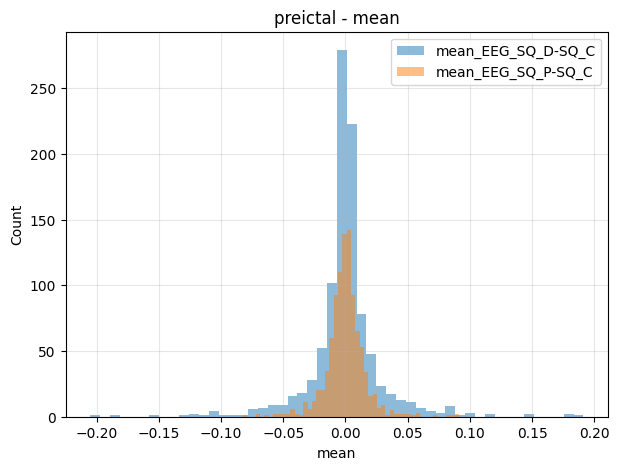

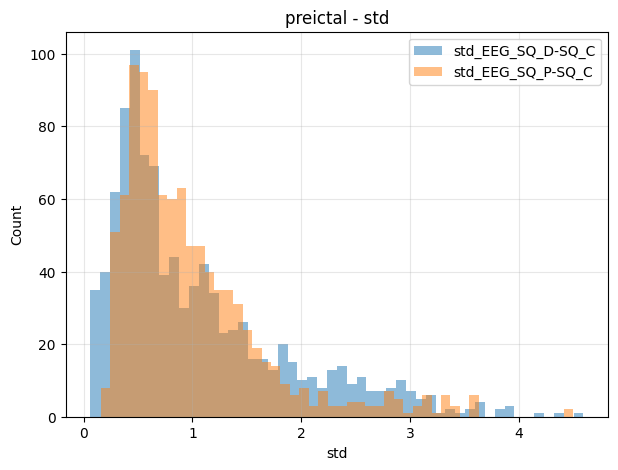

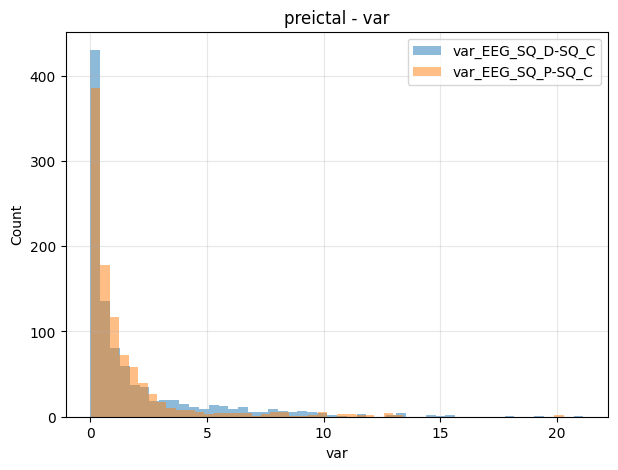

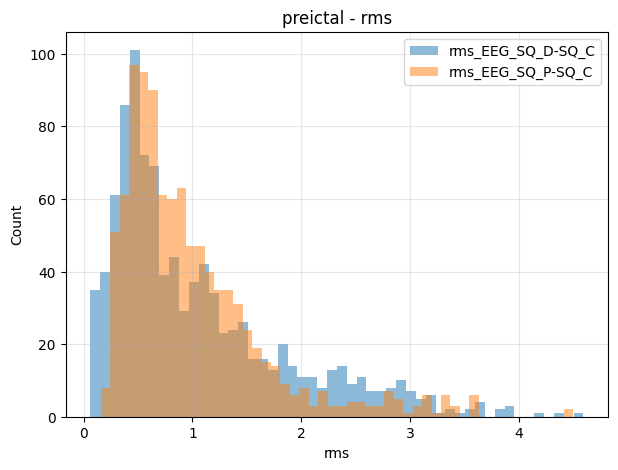

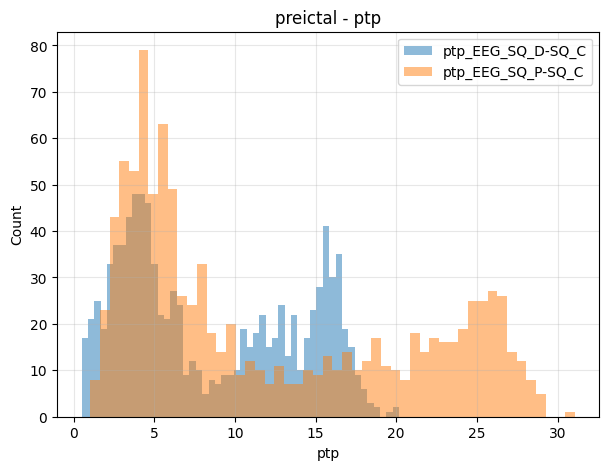

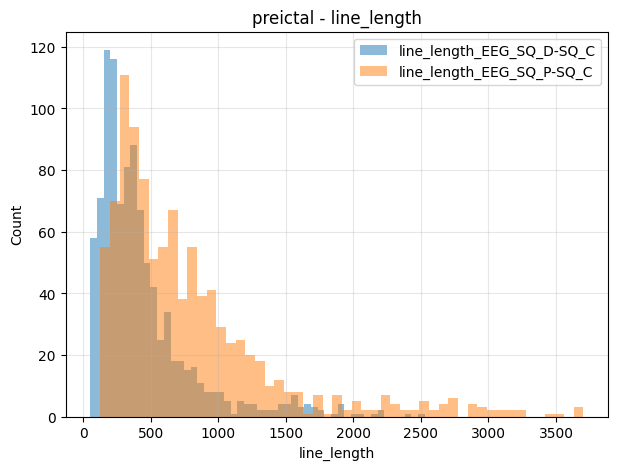

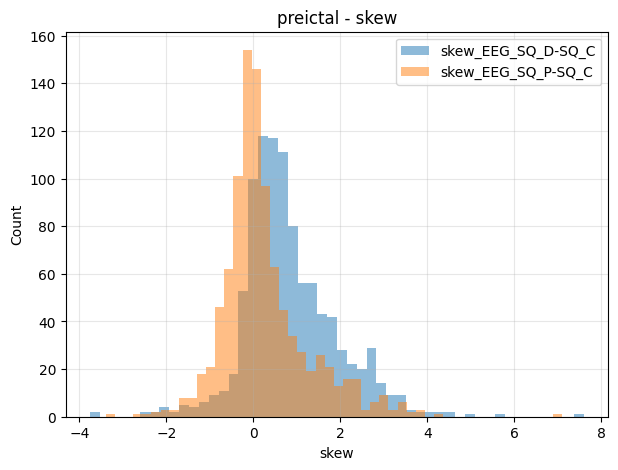

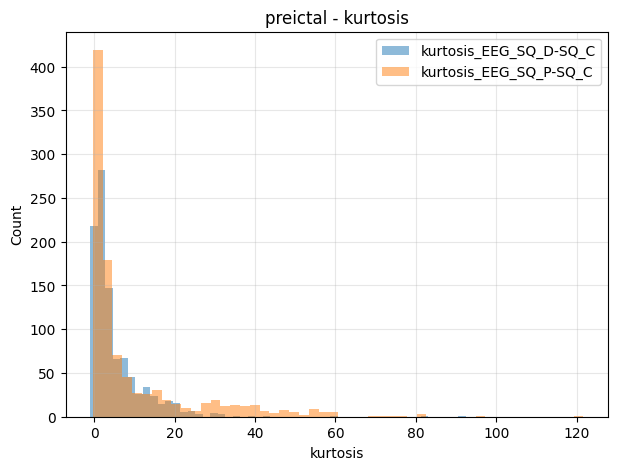


Plotting group: non_preictal


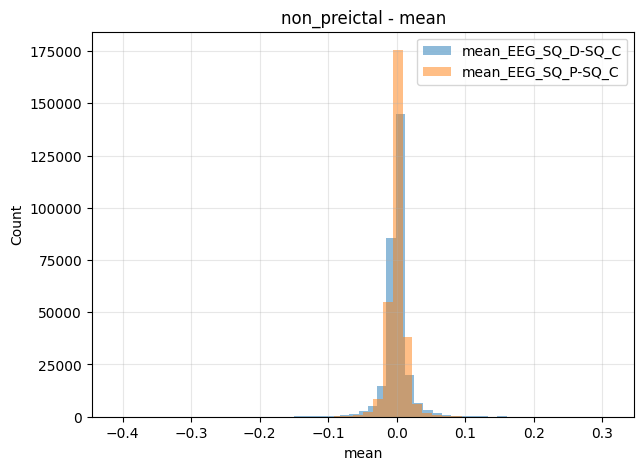

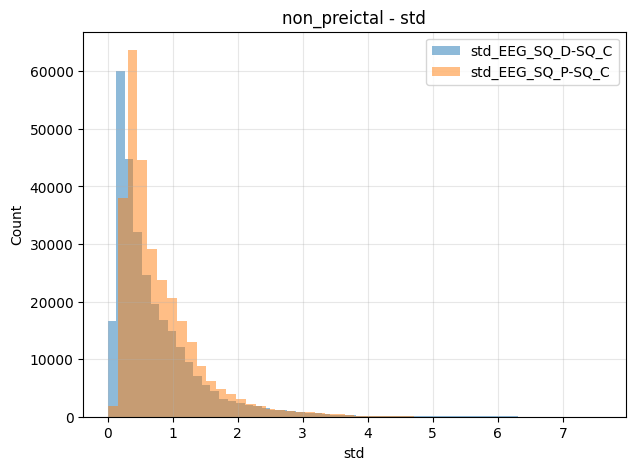

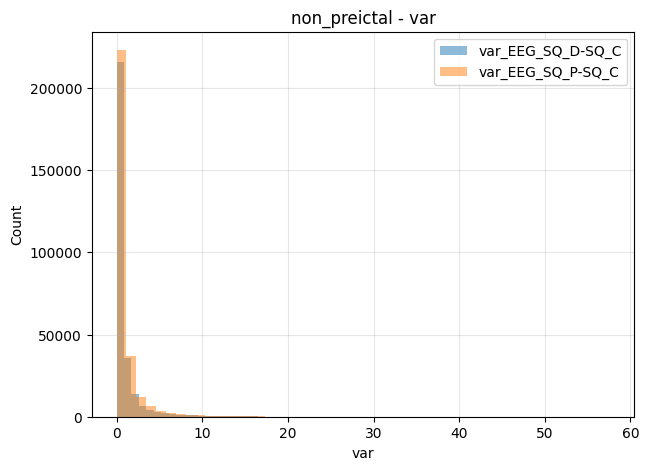

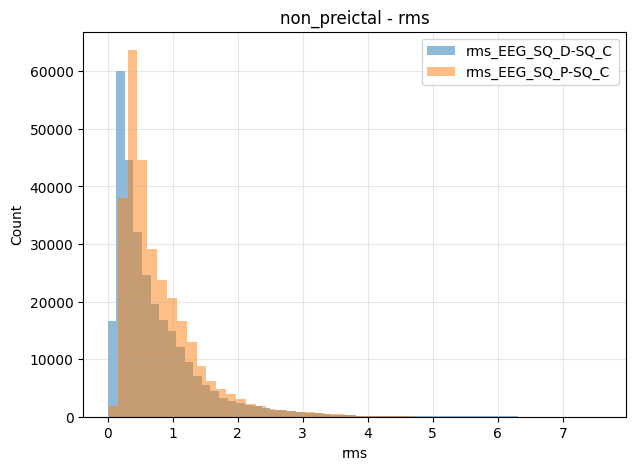

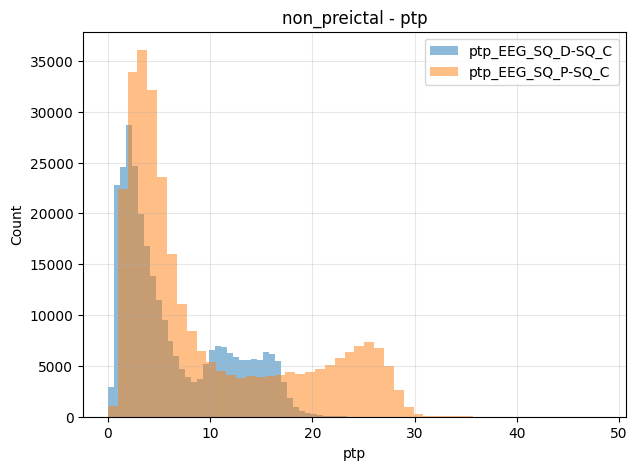

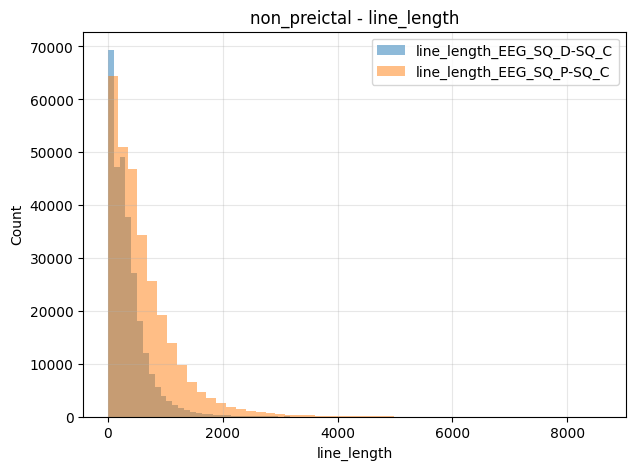

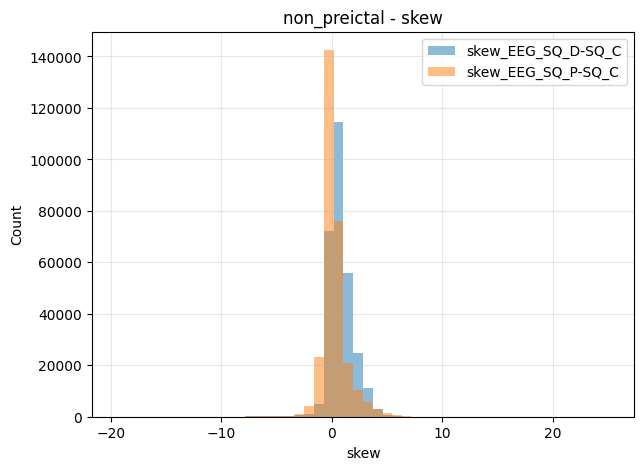

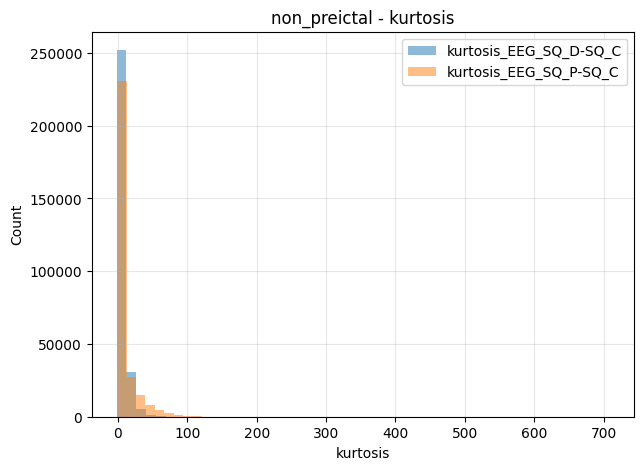


Plotting group: non_preictal_sampled


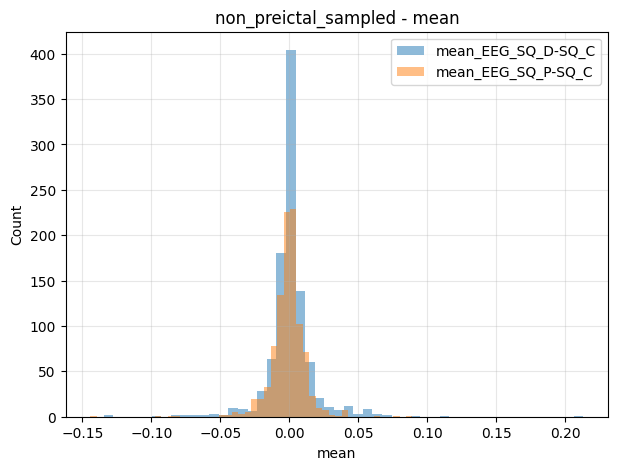

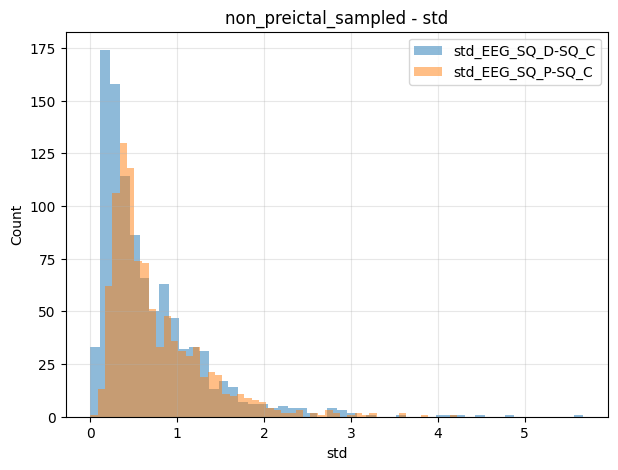

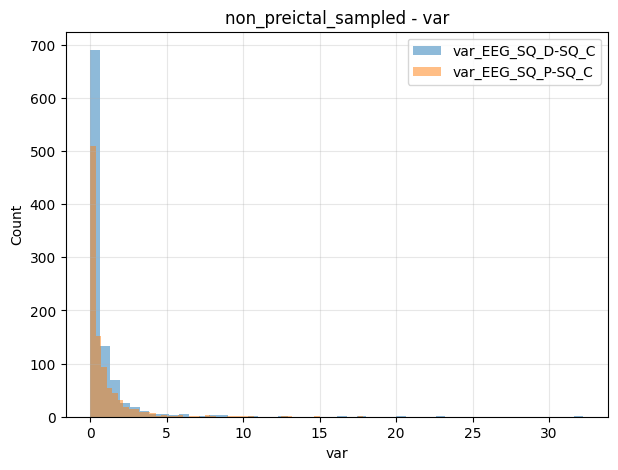

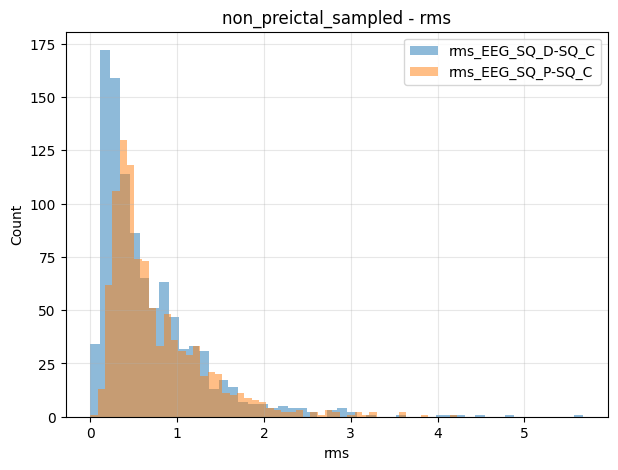

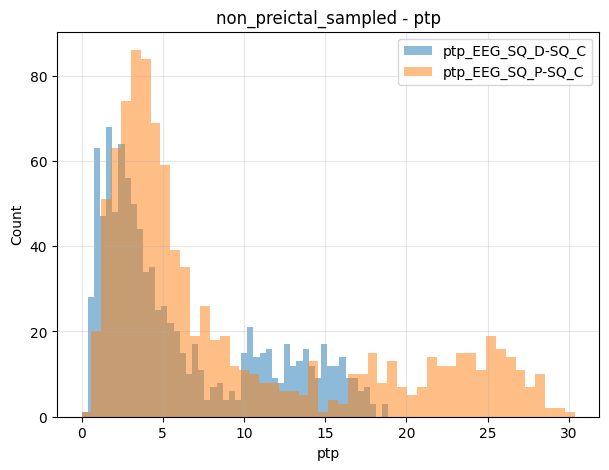

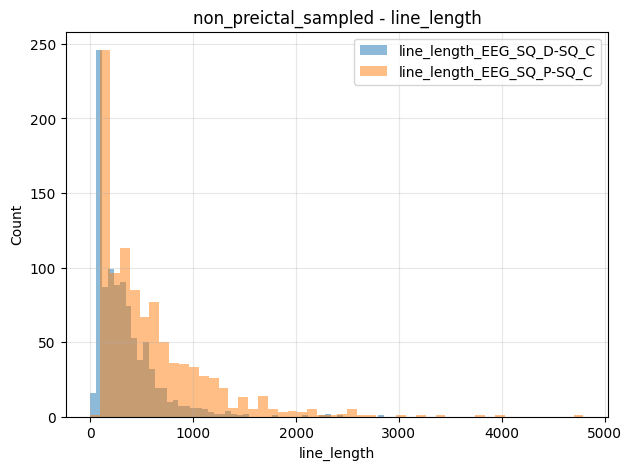

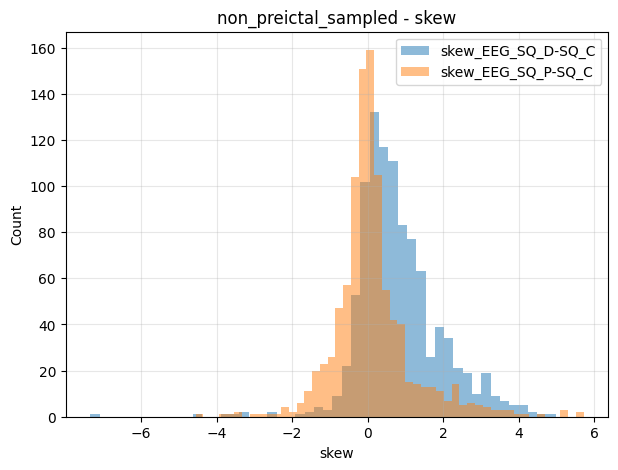

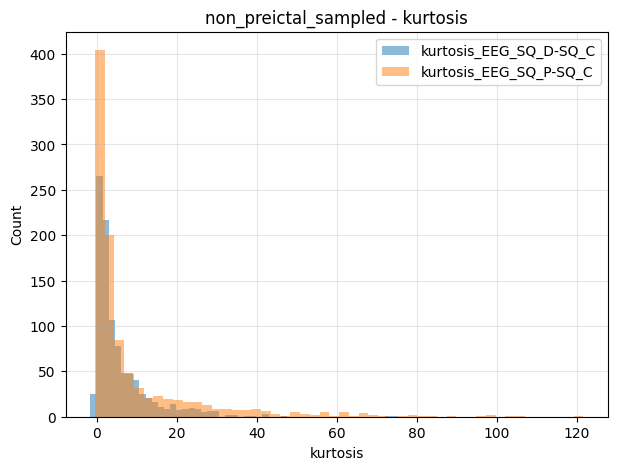

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

groups = {
    "preictal": df_preictal,
    "non_preictal": df_non_preictal,
    "non_preictal_sampled": df_non_preictal_sampled,
}

base_features = ["mean", "std", "var", "rms", "ptp", "line_length", "skew", "kurtosis"]

for group_name, df_to_plot in groups.items():
    
    print(f"\nPlotting group: {group_name}")
    
    for feat in base_features:
        feat_cols = [col for col in df_to_plot.columns if col.startswith(f"{feat}_")]
        
        if len(feat_cols) < 2:
            print(f"Skipping {feat} in {group_name}: less than 2 channel columns found.")
            continue
        
        plt.figure(figsize=(7, 5))
        
        plotted_any = False
        
        for col in feat_cols:
            # Keep only finite values
            values = df_to_plot[col].replace([np.inf, -np.inf], np.nan).dropna()
            values = values[np.isfinite(values)]
            
            if len(values) == 0:
                print(f"Skipping column {col}: no finite values.")
                continue
            
            plt.hist(
                values,
                bins=50,
                alpha=0.5,
                label=col
            )
            plotted_any = True
        
        if plotted_any:
            plt.title(f"{group_name} - {feat}")
            plt.xlabel(feat)
            plt.ylabel("Count")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        else:
            plt.close()
            print(f"No valid data to plot for {group_name} - {feat}")


Plotting feature: mean


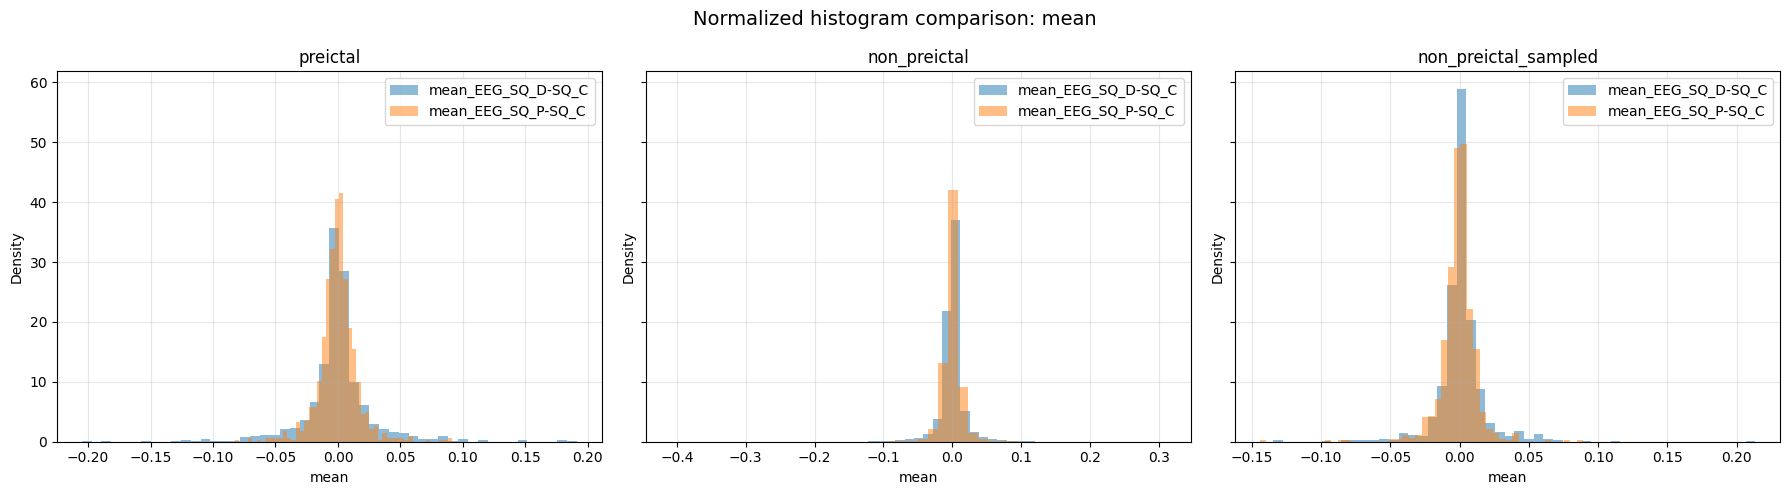


Plotting feature: std


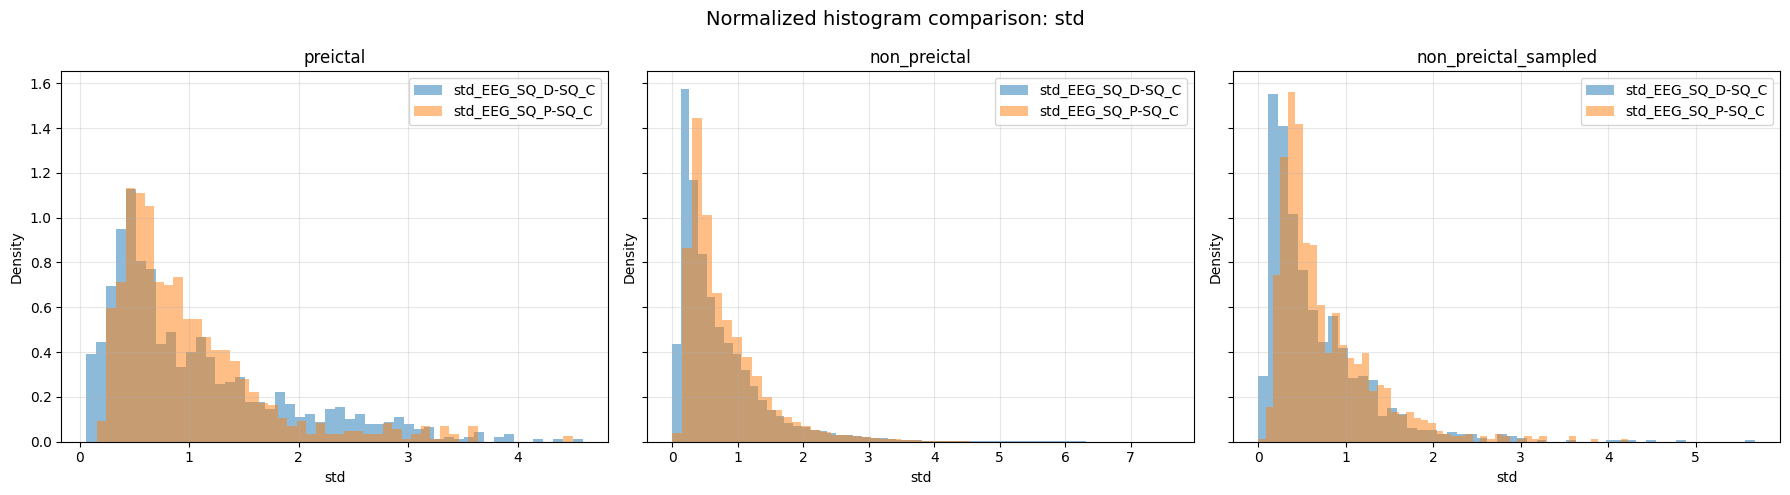


Plotting feature: var


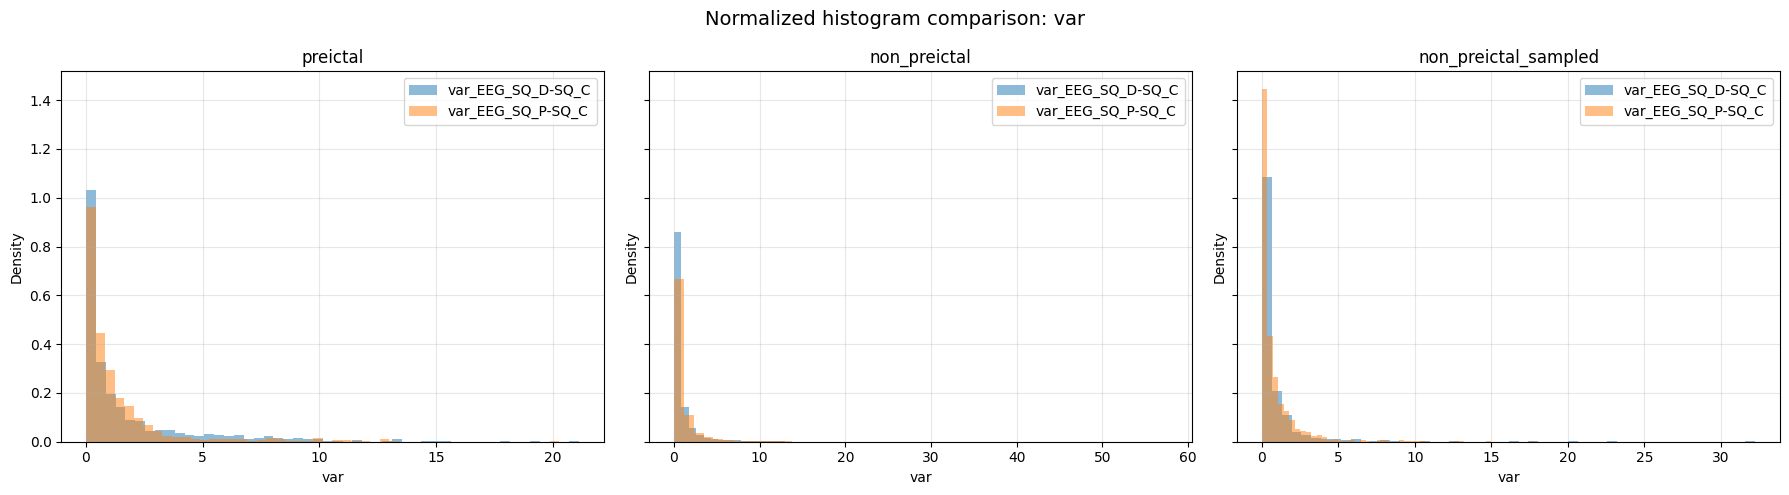


Plotting feature: rms


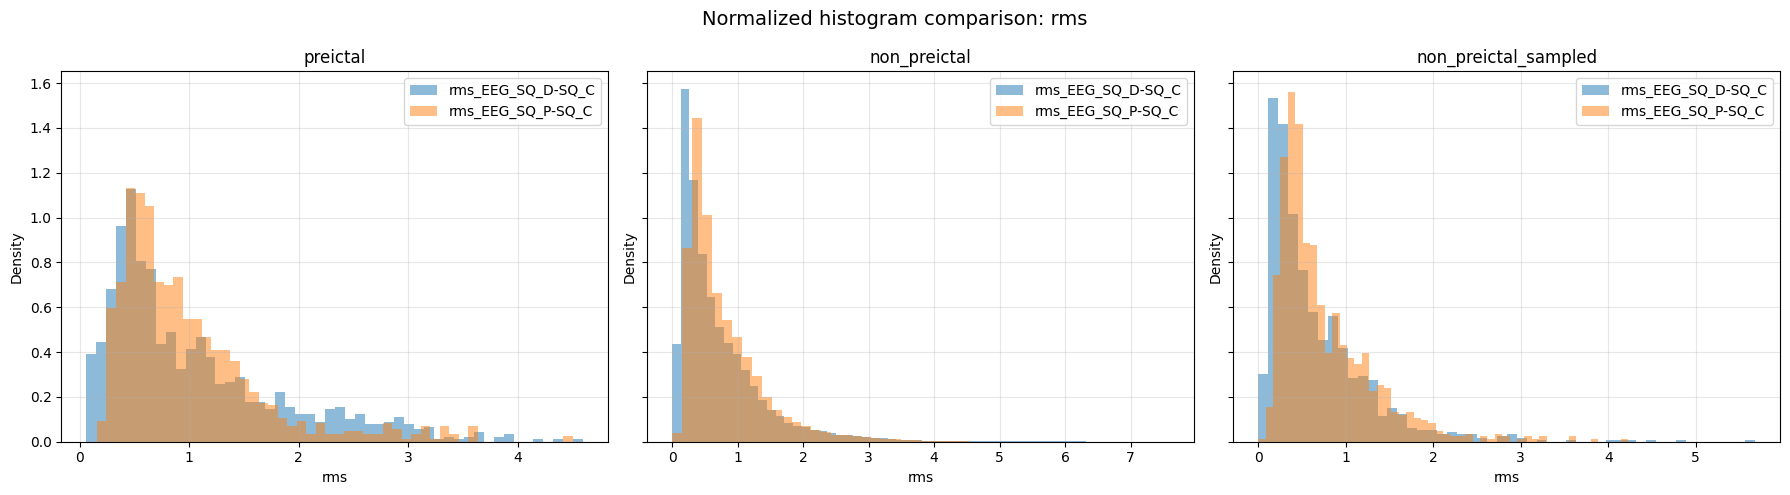


Plotting feature: ptp


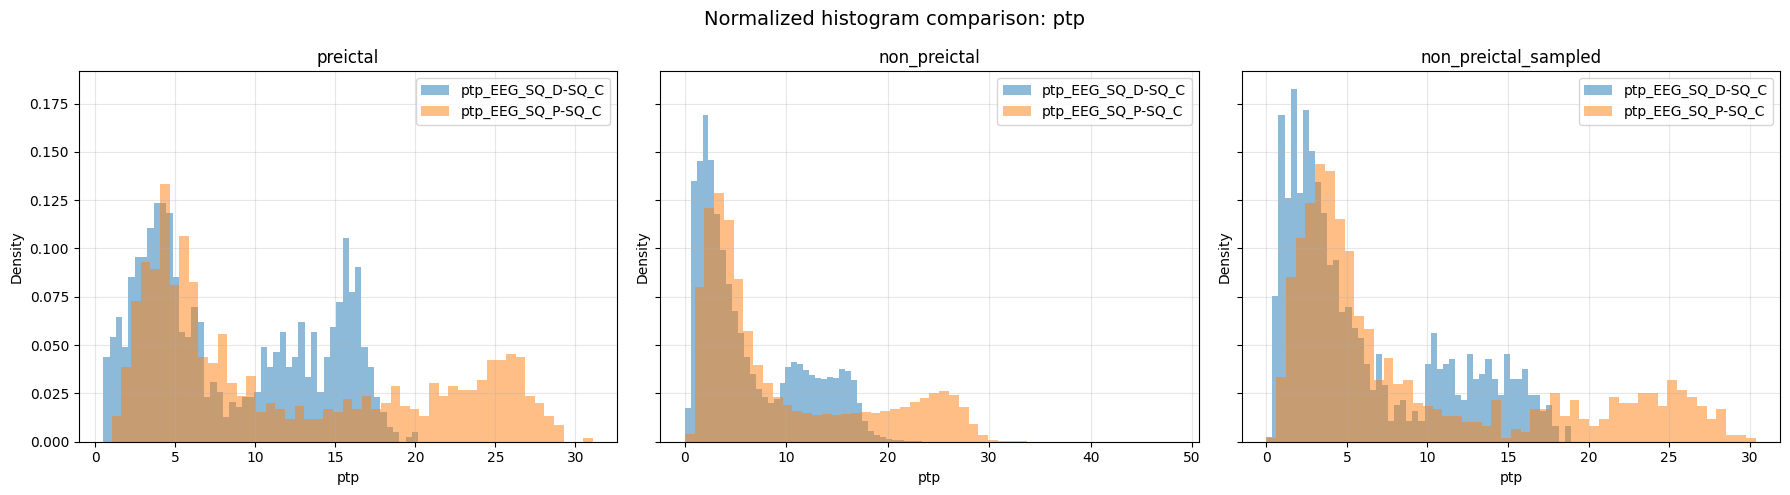


Plotting feature: line_length


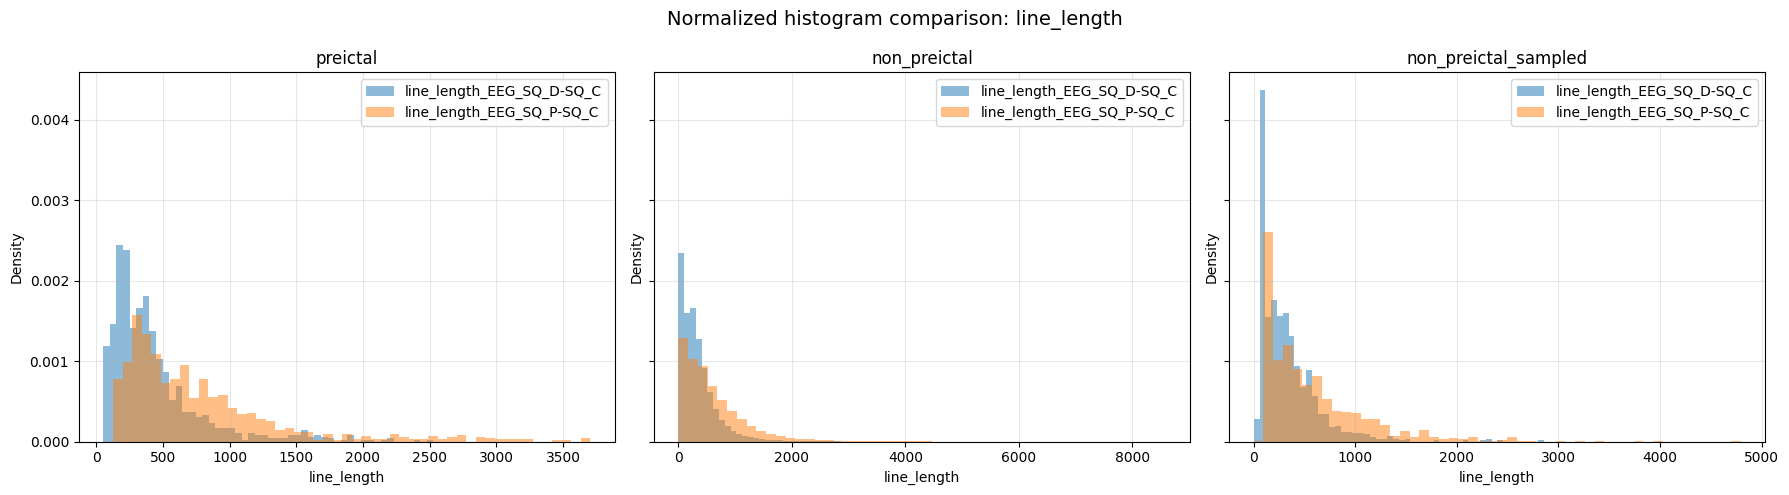


Plotting feature: skew


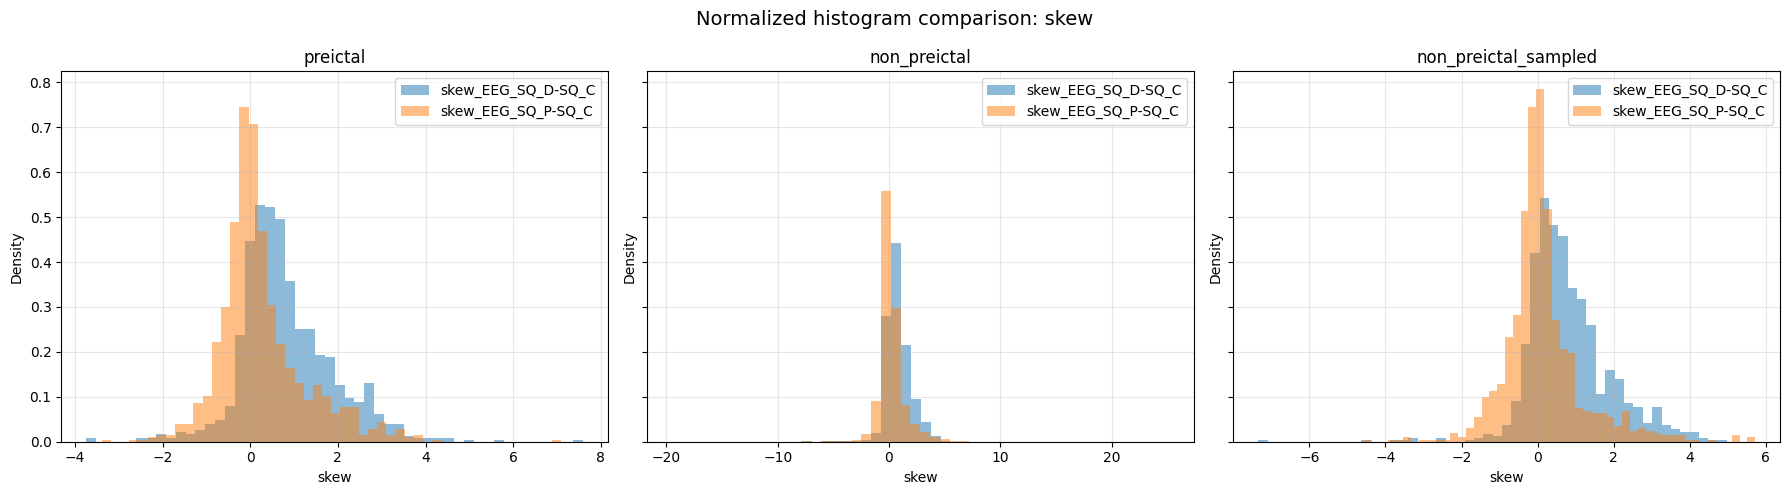


Plotting feature: kurtosis


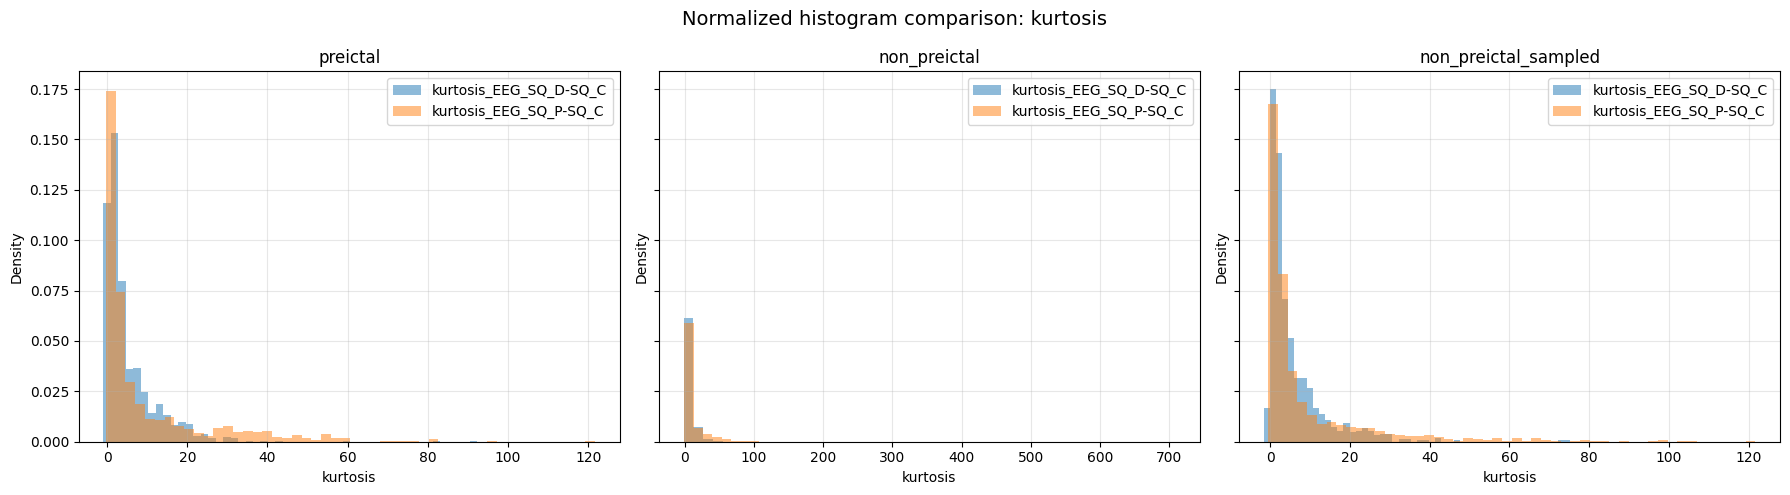

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

groups = {
    "preictal": df_preictal,
    "non_preictal": df_non_preictal,
    "non_preictal_sampled": df_non_preictal_sampled,
}

base_features = ["mean", "std", "var", "rms", "ptp", "line_length", "skew", "kurtosis"]

for feat in base_features:
    print(f"\nPlotting feature: {feat}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    
    plotted_any = False
    
    for ax, (group_name, df_to_plot) in zip(axes, groups.items()):
        feat_cols = [col for col in df_to_plot.columns if col.startswith(f"{feat}_")]
        
        if len(feat_cols) < 2:
            ax.set_title(f"{group_name}\n(not enough columns)")
            ax.axis("off")
            continue
        
        group_plotted = False
        
        for col in feat_cols:
            values = df_to_plot[col].replace([np.inf, -np.inf], np.nan).dropna()
            values = values[np.isfinite(values)]
            
            if len(values) == 0:
                continue
            
            ax.hist(
                values,
                bins=50,
                alpha=0.5,
                label=col,
                density=True   #normalizatiom
            )
            
            group_plotted = True
            plotted_any = True
        
        if group_plotted:
            ax.set_title(group_name)
            ax.set_xlabel(feat)
            ax.set_ylabel("Density")  
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{group_name}\n(no valid data)")
            ax.axis("off")
    
    if plotted_any:
        fig.suptitle(f"Normalized histogram comparison: {feat}", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
        print(f"No valid data found for feature: {feat}")

#### 5.2.2 Boxplots 


Plotting feature: mean


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


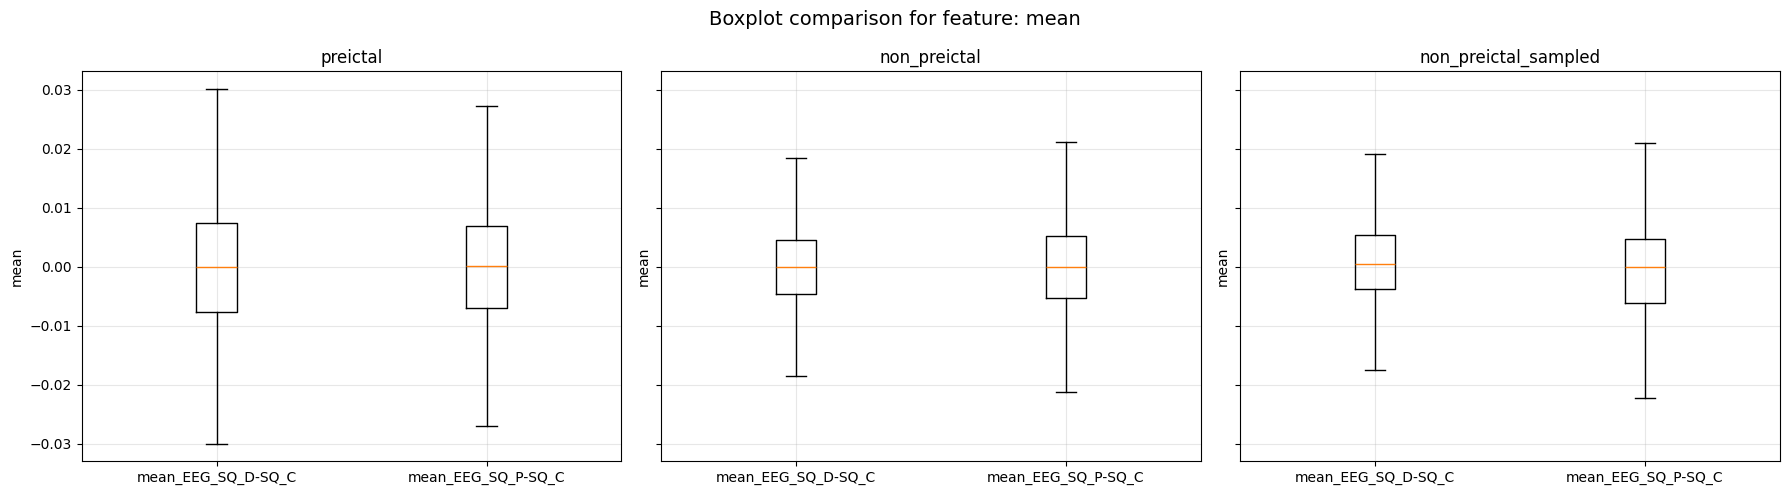


Plotting feature: std


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


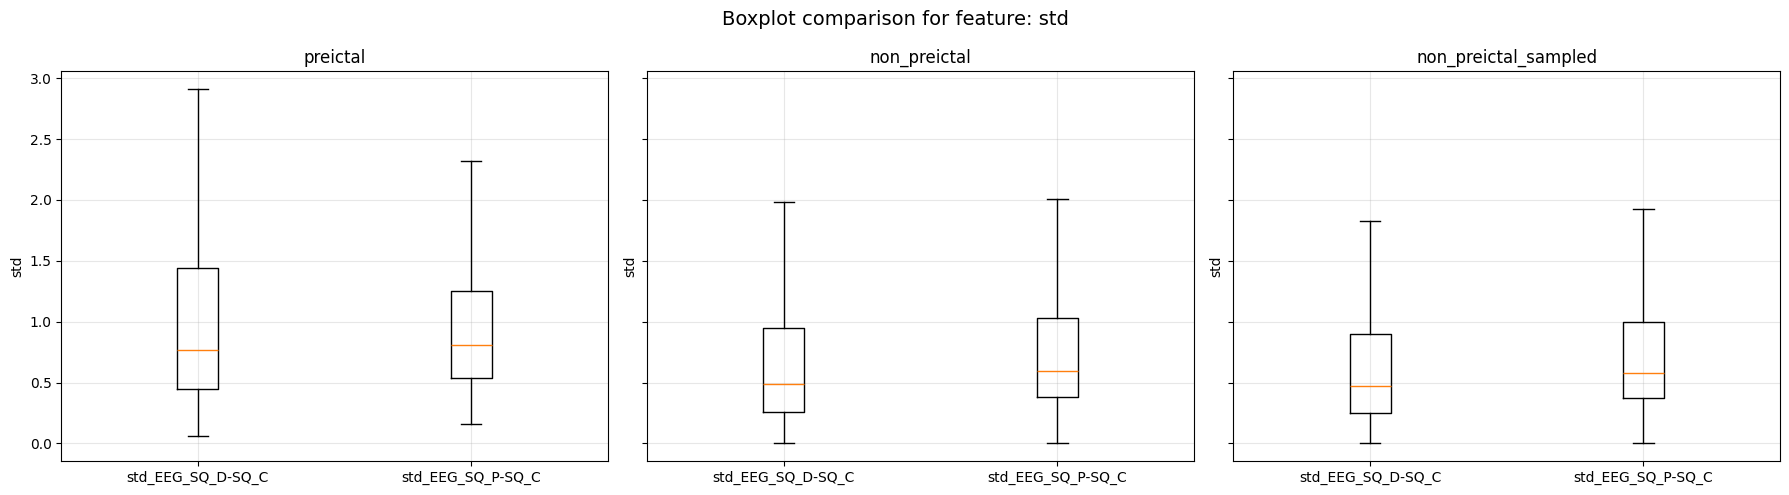


Plotting feature: var


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


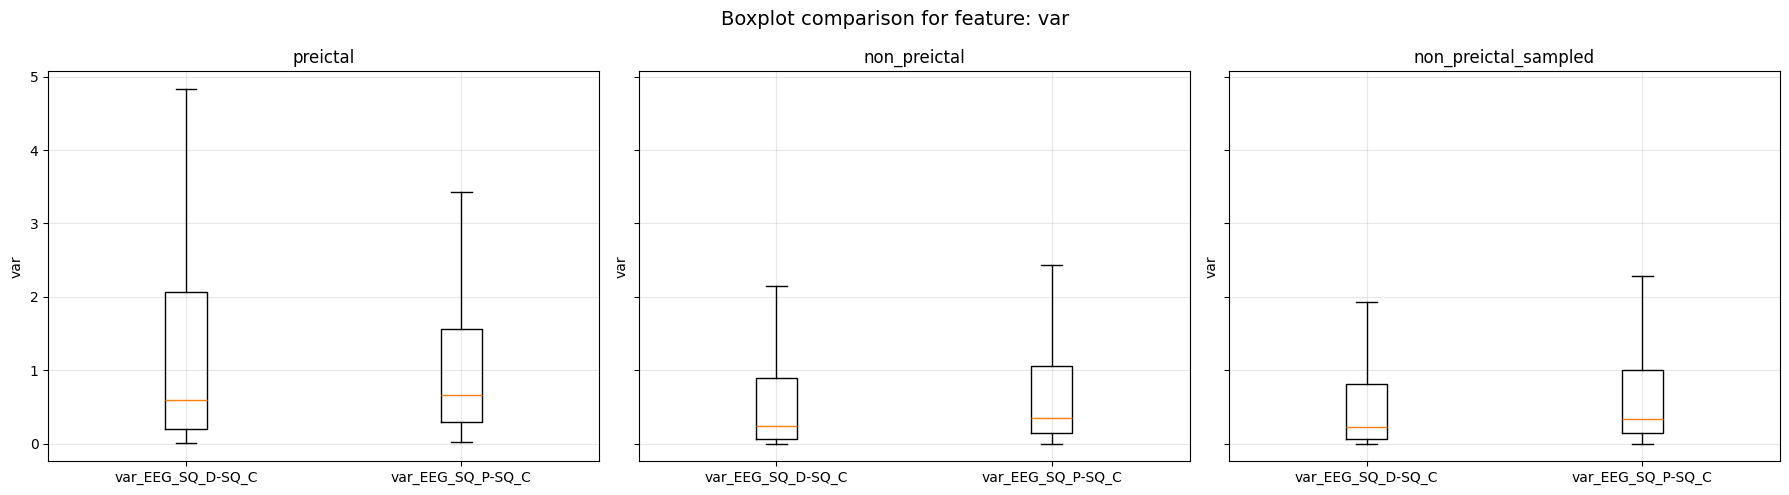


Plotting feature: rms


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


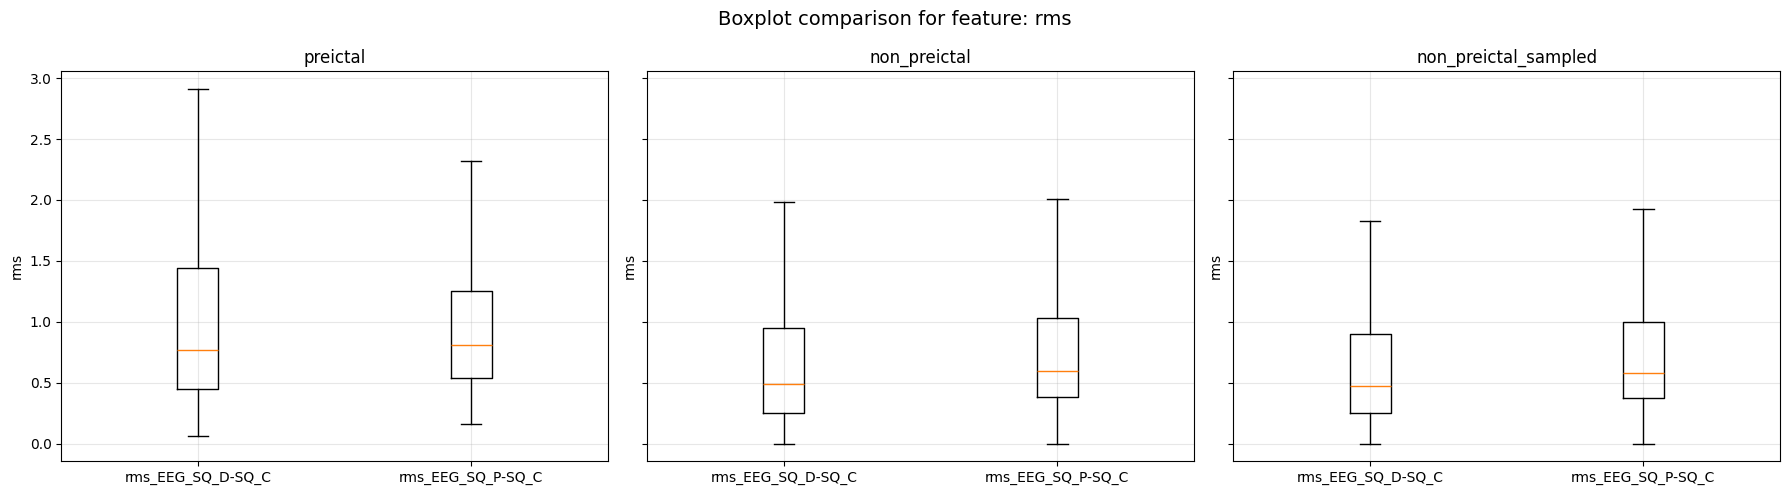


Plotting feature: ptp


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


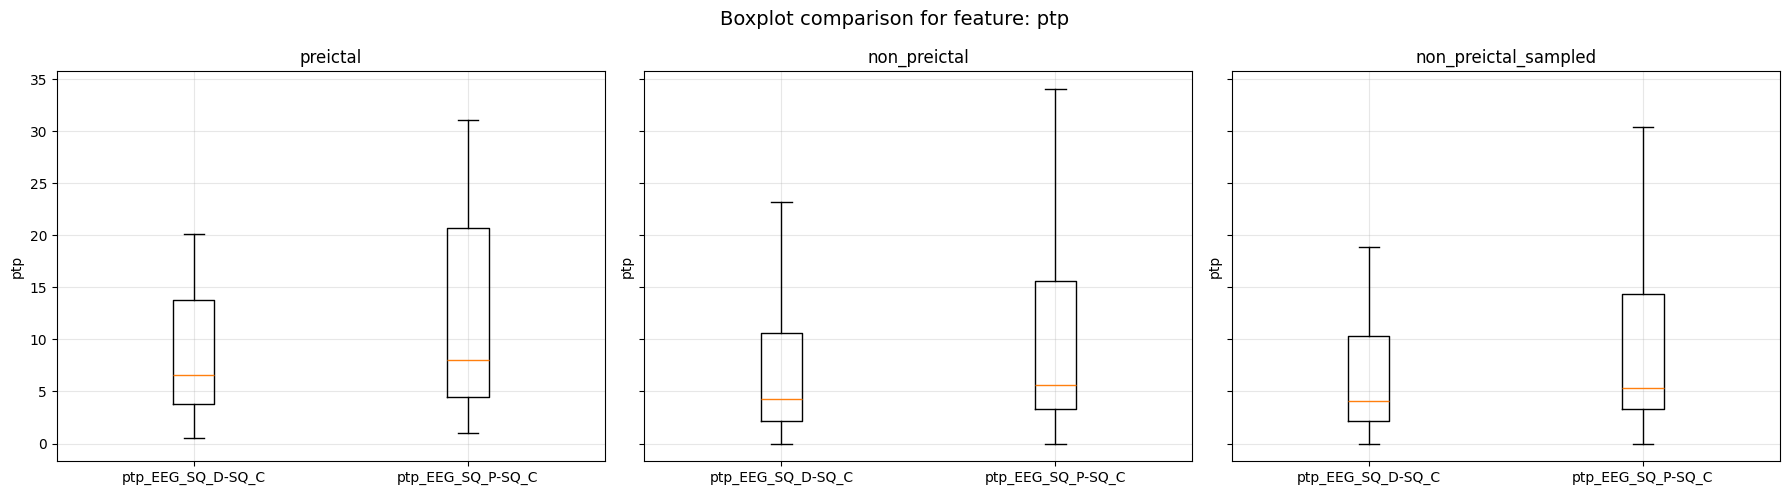


Plotting feature: line_length


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


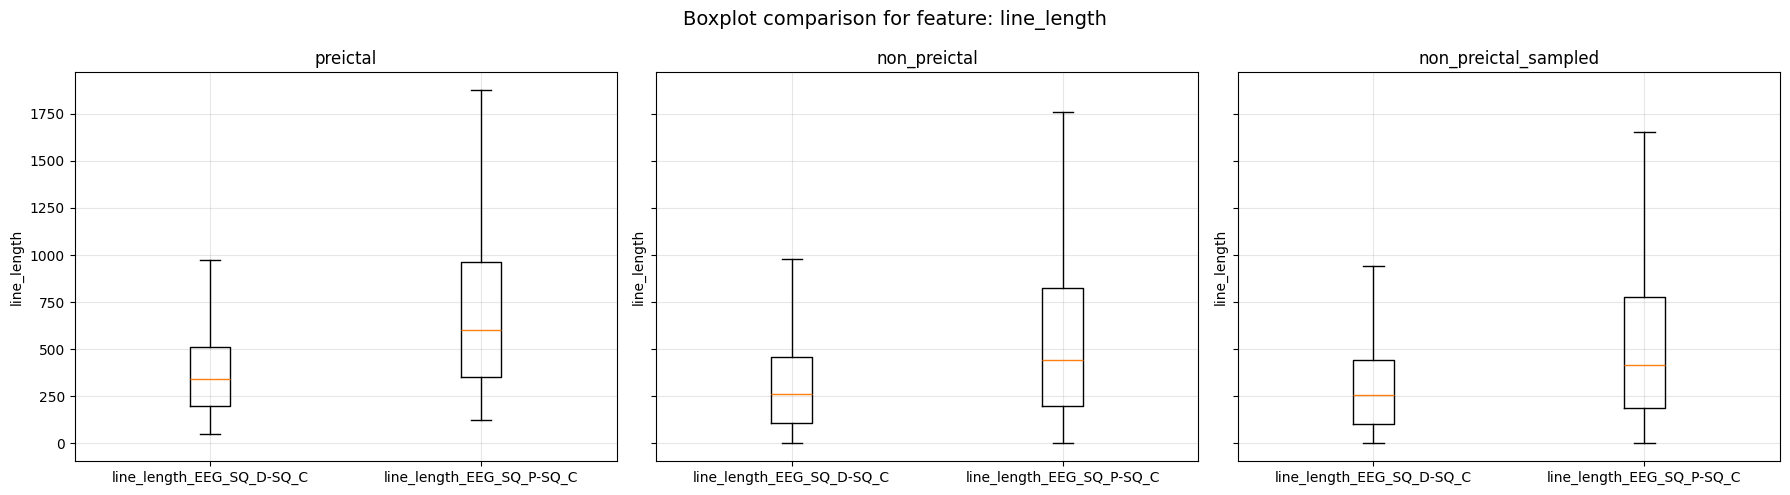


Plotting feature: skew


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


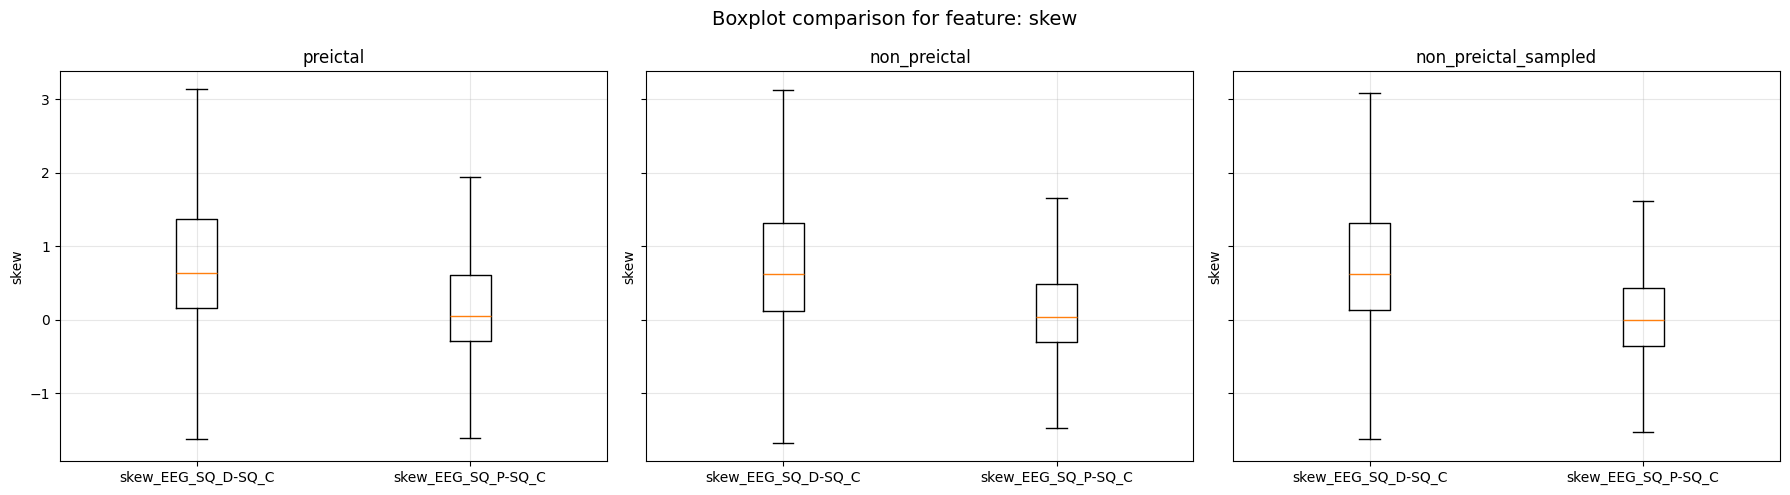


Plotting feature: kurtosis


/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)
/tmp/ipykernel_76916/454995125.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


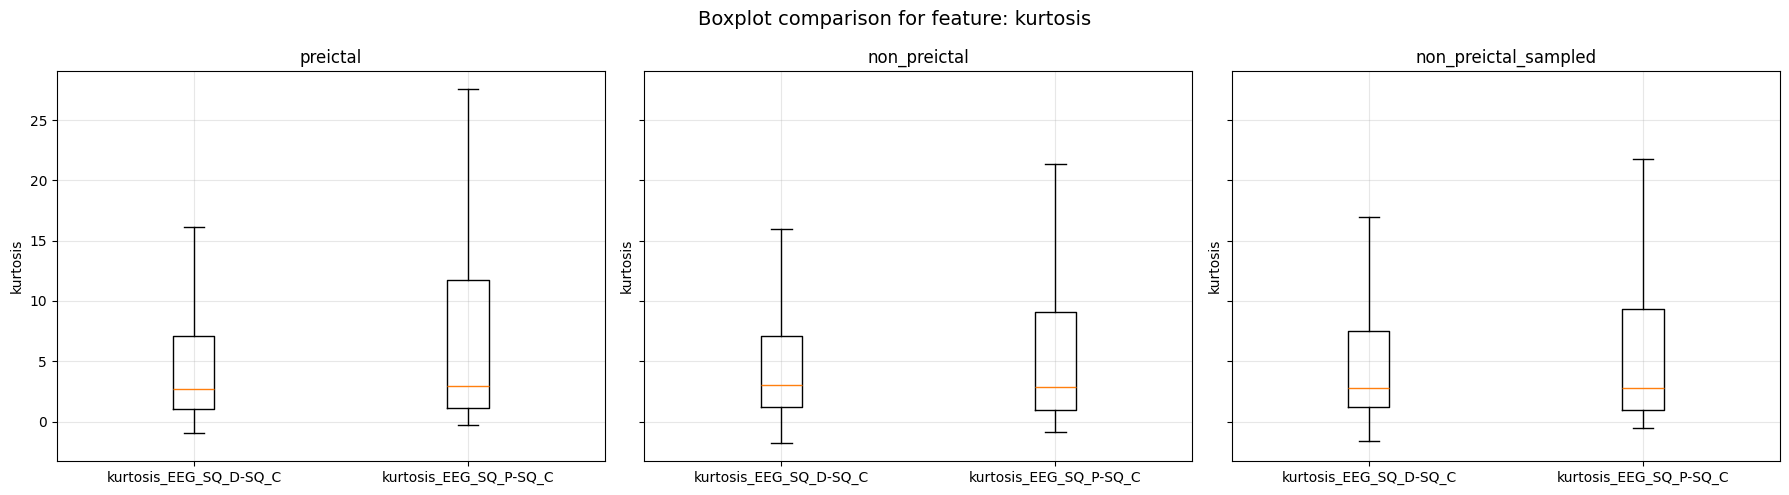

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

groups = {
    "preictal": df_preictal,
    "non_preictal": df_non_preictal,
    "non_preictal_sampled": df_non_preictal_sampled,
}

base_features = ["mean", "std", "var", "rms", "ptp", "line_length", "skew", "kurtosis"]

for feat in base_features:
    print(f"\nPlotting feature: {feat}")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    plotted_any = False
    
    for ax, (group_name, df_to_plot) in zip(axes, groups.items()):
        feat_cols = [col for col in df_to_plot.columns if col.startswith(f"{feat}_")]
        
        data_to_plot = []
        labels = []
        
        for col in feat_cols:
            values = df_to_plot[col].replace([np.inf, -np.inf], np.nan).dropna()
            values = values[np.isfinite(values)]
            
            if len(values) == 0:
                continue
            
            data_to_plot.append(values)
            labels.append(col)
            plotted_any = True
        
        if len(data_to_plot) > 0:
            ax.boxplot(data_to_plot, labels=labels, showfliers=False)
            ax.set_title(group_name)
            ax.set_ylabel(feat)
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{group_name}\n(no valid data)")
            ax.axis("off")
    
    if plotted_any:
        fig.suptitle(f"Boxplot comparison for feature: {feat}", fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
        print(f"No valid data found for feature: {feat}")

## 6. SVM
the machine needs to identify what combinations of features does represent a pre-ictal period. Does it works like this? 
the input is going to be each row. so the classifier needs to correcly allocate each row according to its label. 